In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbWF4L2F1bGEtcXVhbnR1bS9jb250ZW50LzA3LXRlbGV0cmFuc3BvcnRl'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap_external.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/codecs.py": 1787687116.7980936, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/aliases.py": 1787687116.852094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/__init__.py": 1787687116.8510938, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/utf_8.py": 1787687116.888094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/abc.py": 1787687116.7790935, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/io.py": 1787687117.0350945, "/home/max/.local/share/uv/python/cpython-3.10-linu

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere, plot_state_city
from numpy import pi

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


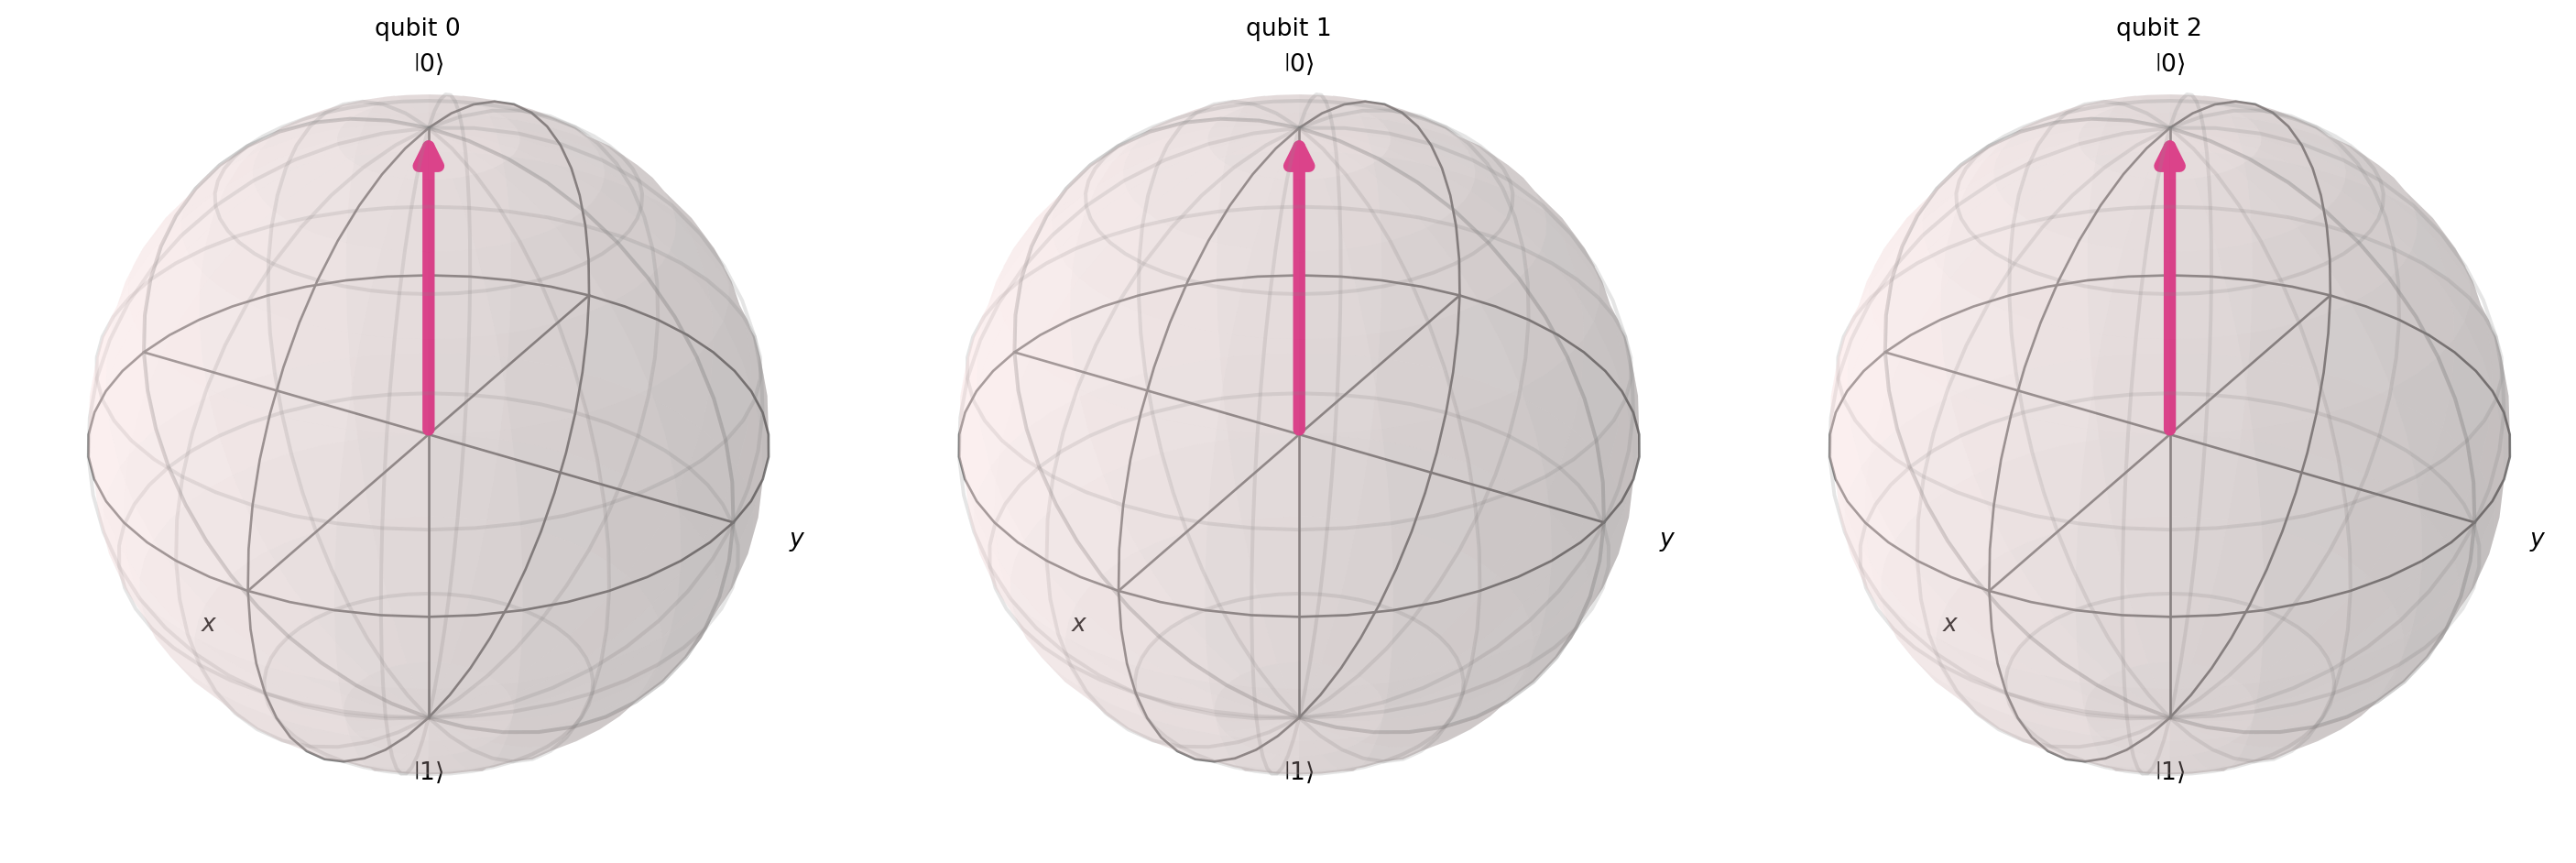

In [3]:
qreg_q = QuantumRegister(3, 'q')
creg_c = ClassicalRegister(3, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)
circuit.draw('mpl')

state1 = Statevector.from_instruction(circuit)
print(state1)
plot_bloch_multivector(state1)

Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


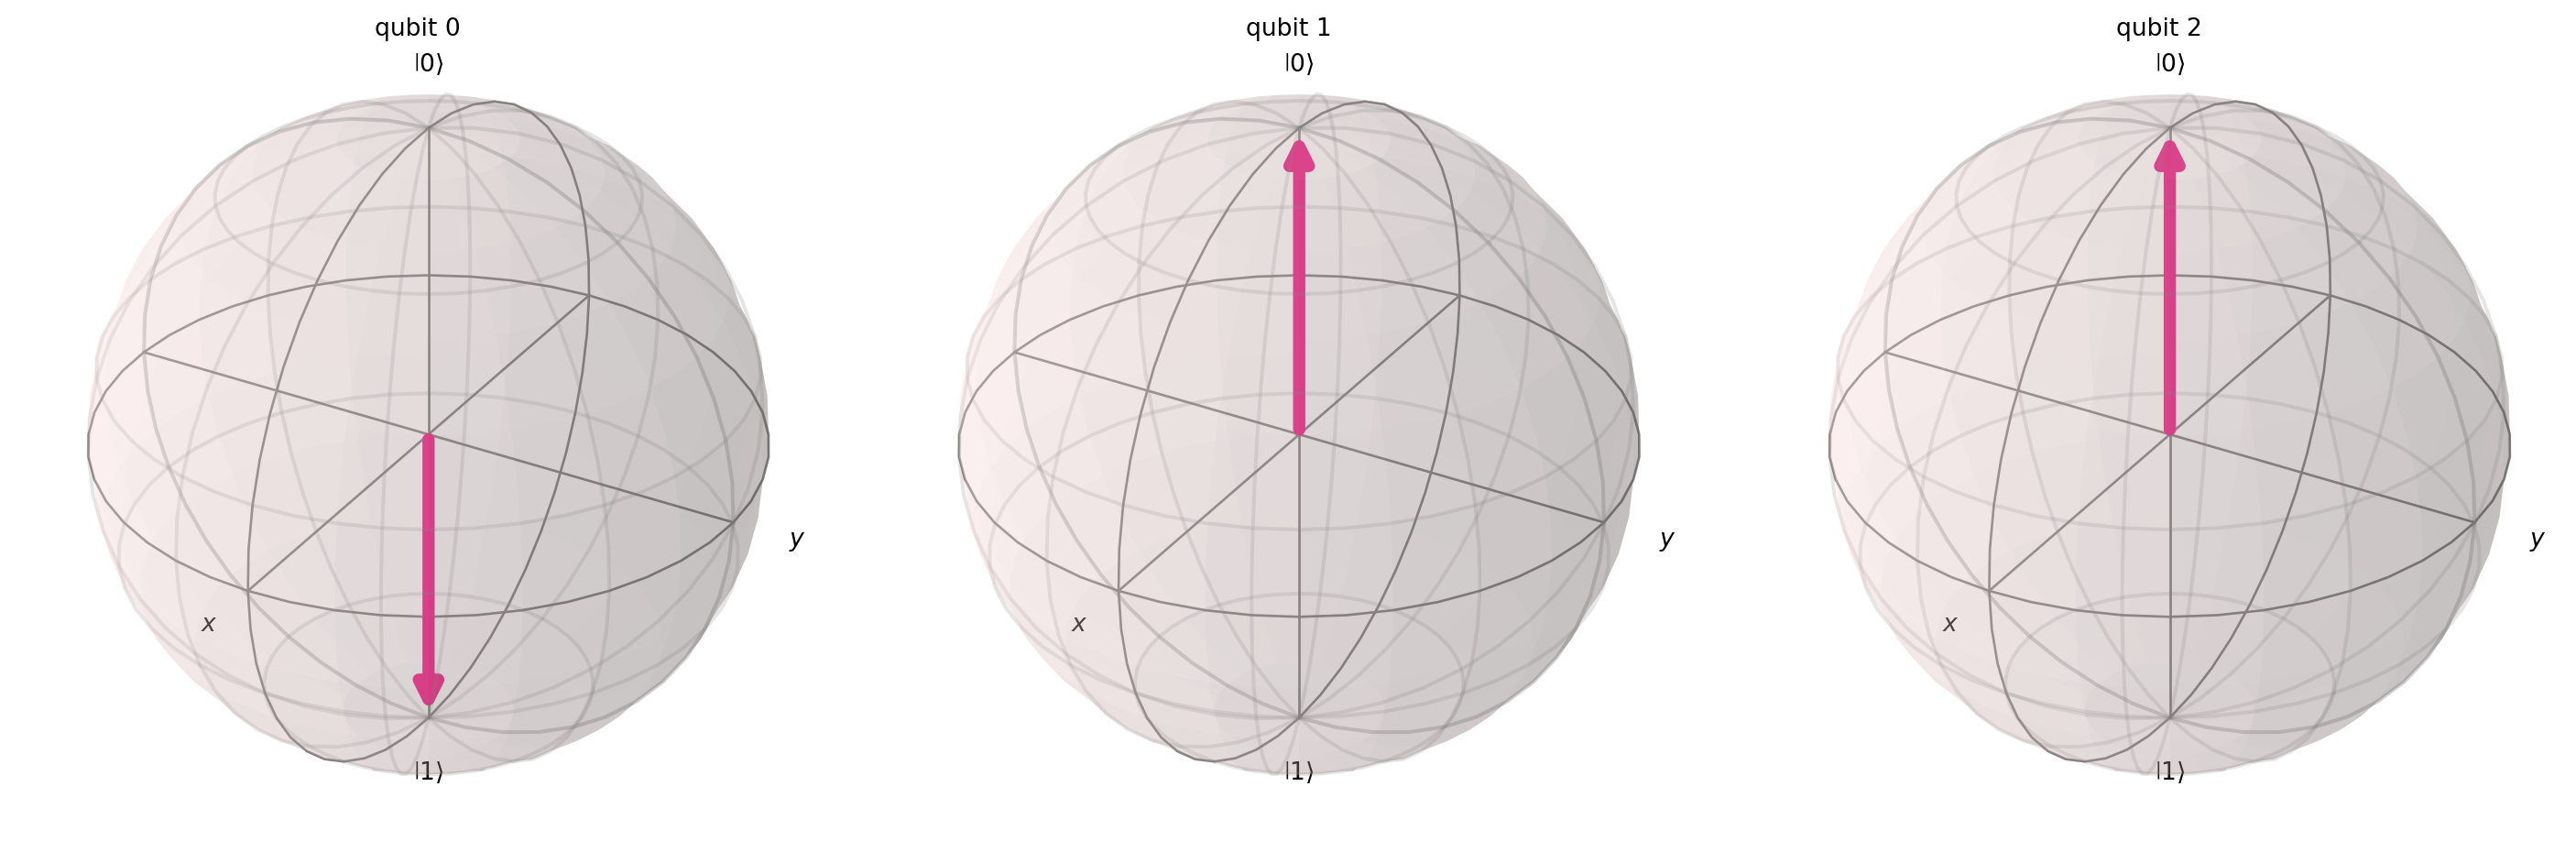

In [4]:
circuit.x(qreg_q[0])
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2])

circuit.draw('mpl')
state2 = Statevector.from_instruction(circuit)
print(state2)
plot_bloch_multivector(state2)

Statevector([0.        +0.j, 0.70710678+0.j, 0.        +0.j,
             0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))


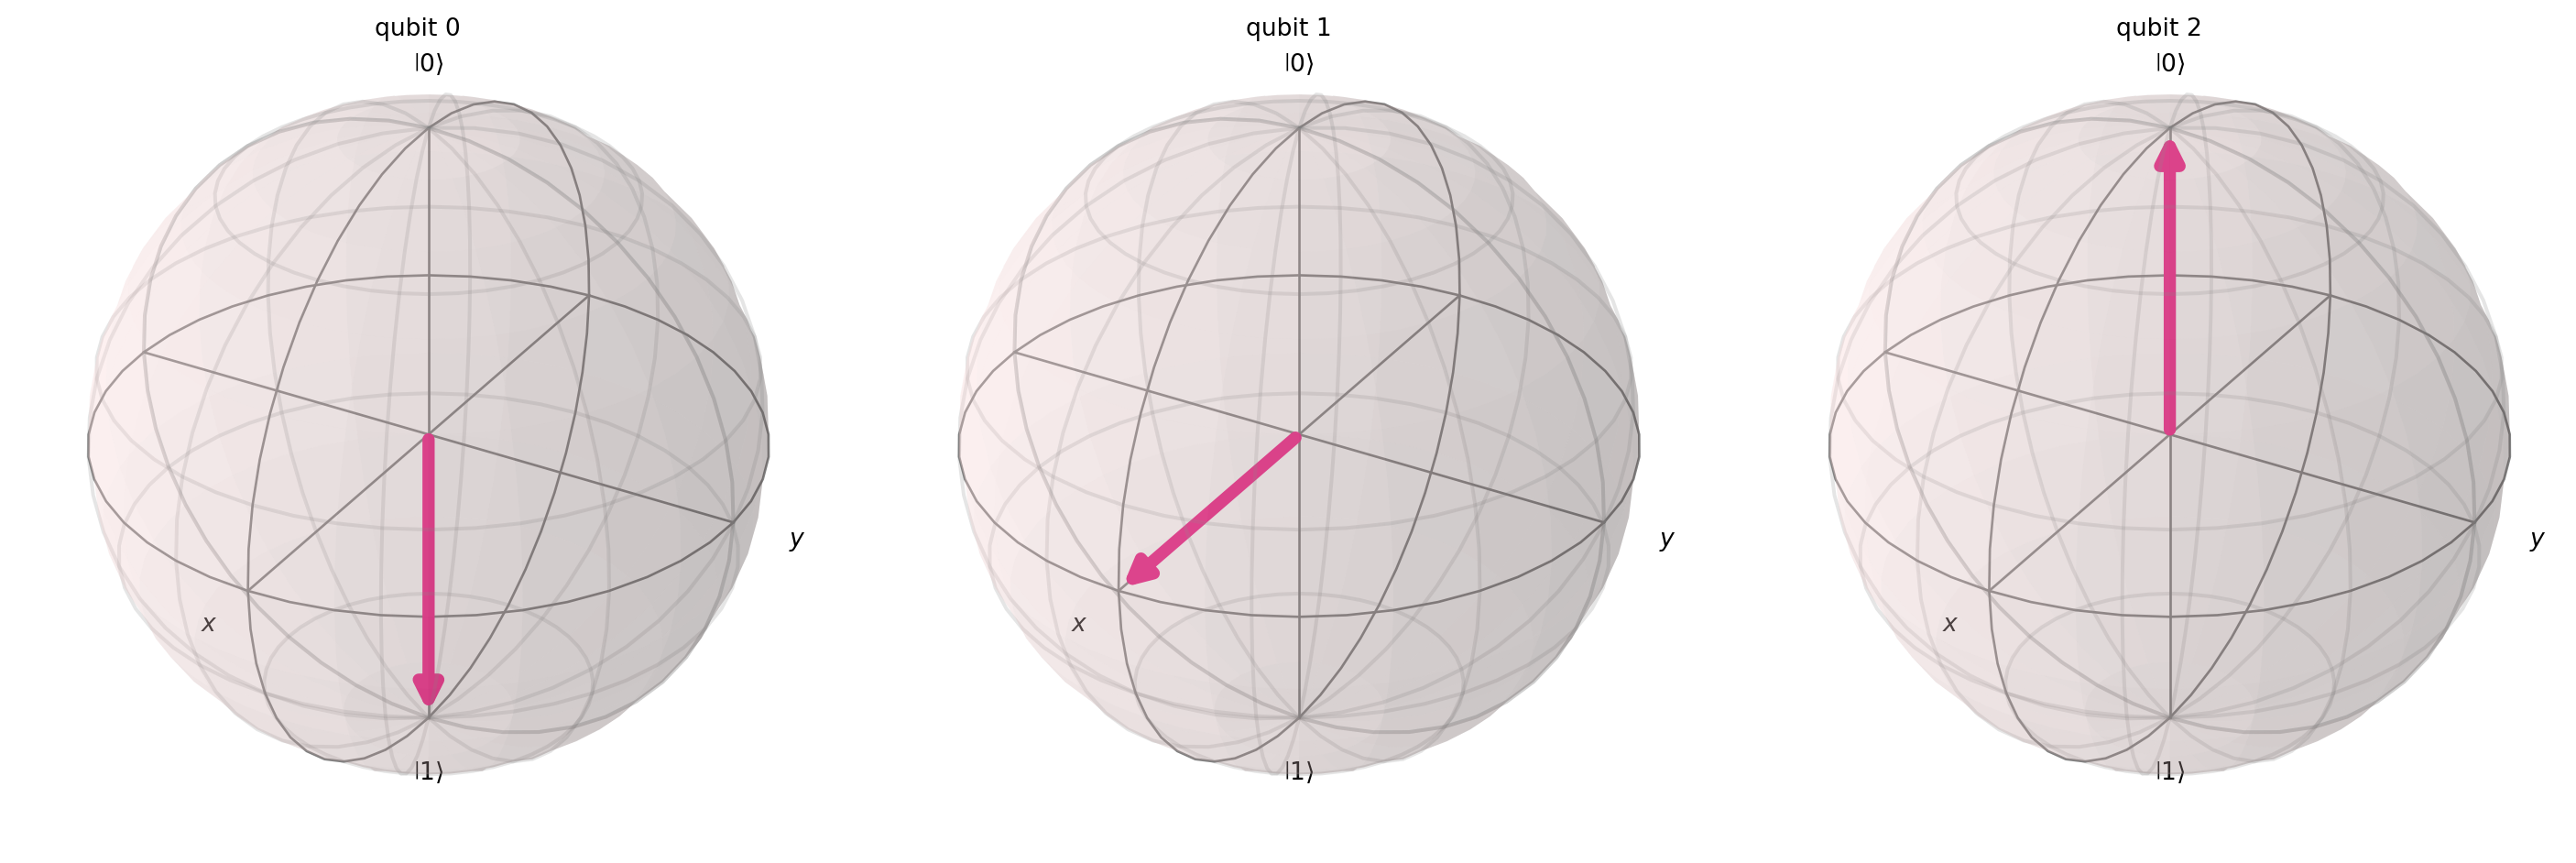

In [5]:
circuit.h(qreg_q[1])

state3 = Statevector.from_instruction(circuit)
print(state3)
plot_bloch_multivector(state3)

In [6]:
circuit.cx(qreg_q[1], qreg_q[2])

state4 = Statevector.from_instruction(circuit)
print(state4)

Statevector([0.        +0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))



🌐 Q-Sphere (mostra amplitudes e fases do estado completo):


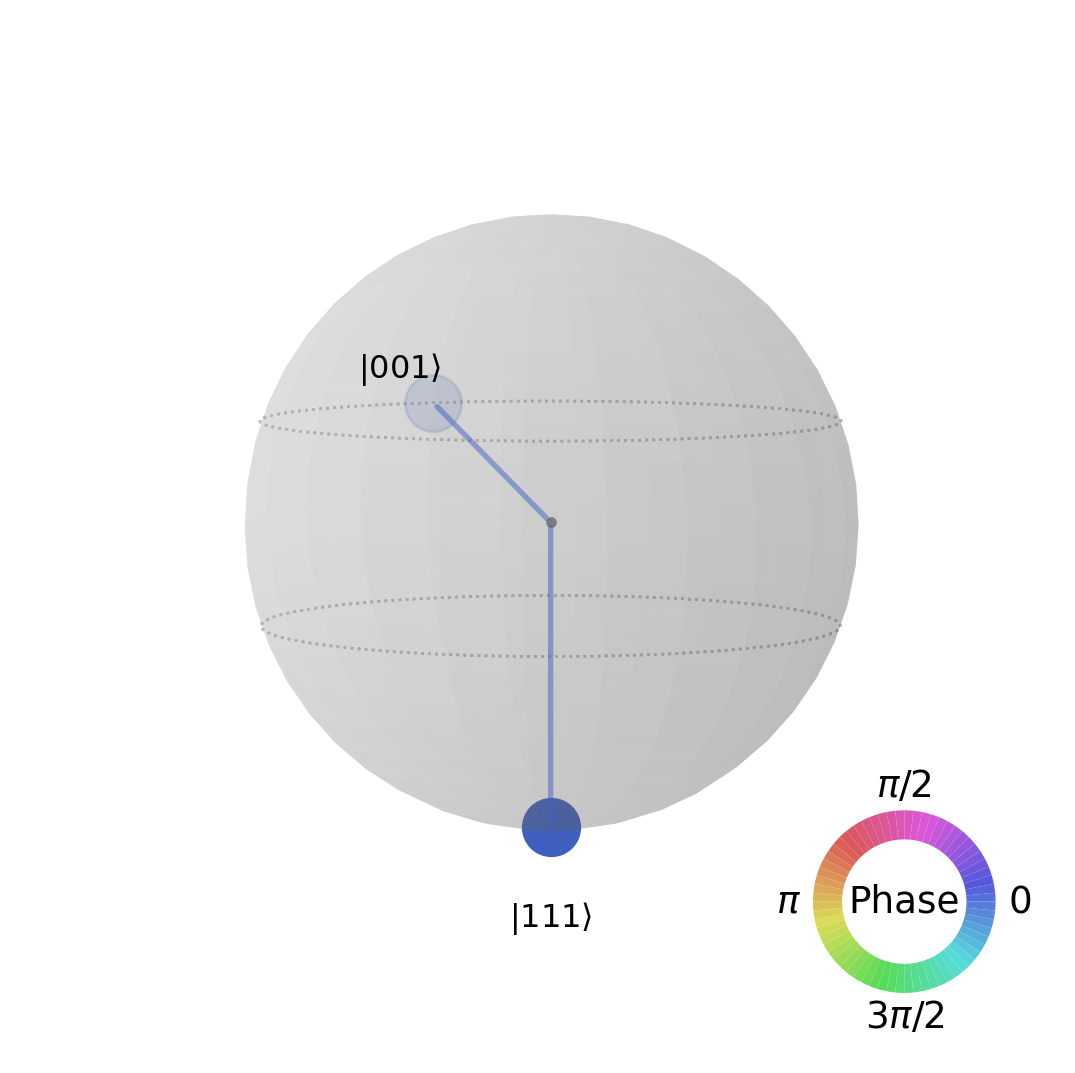

In [7]:
# Visualização na Q-Sphere - melhor para ver emaranhamento!
print("\n🌐 Q-Sphere (mostra amplitudes e fases do estado completo):")
plot_state_qsphere(state4)

In [8]:
# 🌐 Visualização INTERATIVA da Q-Sphere
# Importar a função do módulo quantum_viz (localizado em ../src)
import sys
from pathlib import Path
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (p / "src").is_dir() and str(p / "src") not in sys.path:
        sys.path.insert(0, str(p / "src"))
from quantum_viz import plot_qsphere_interactive

# 🎨 Criar e exibir a visualização
print("\n🌐 Q-Sphere INTERATIVA:")
print("   → Magenta = Fase positiva (+)")
print("   → Ciano = Fase negativa (-)")
print("   → Tamanho = Probabilidade\n")

# A função plot_qsphere_interactive salva automaticamente e abre no navegador
fig = plot_qsphere_interactive(state4)


🌐 Q-Sphere INTERATIVA:
   → Magenta = Fase positiva (+)
   → Ciano = Fase negativa (-)
   → Tamanho = Probabilidade



✅ Visualização 3D salva em: /home/max/aula-quantum/content/07-teletransporte/qsphere_interativa.html


Statevector([0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))

🏙️ State City (visualização 3D da matriz densidade):


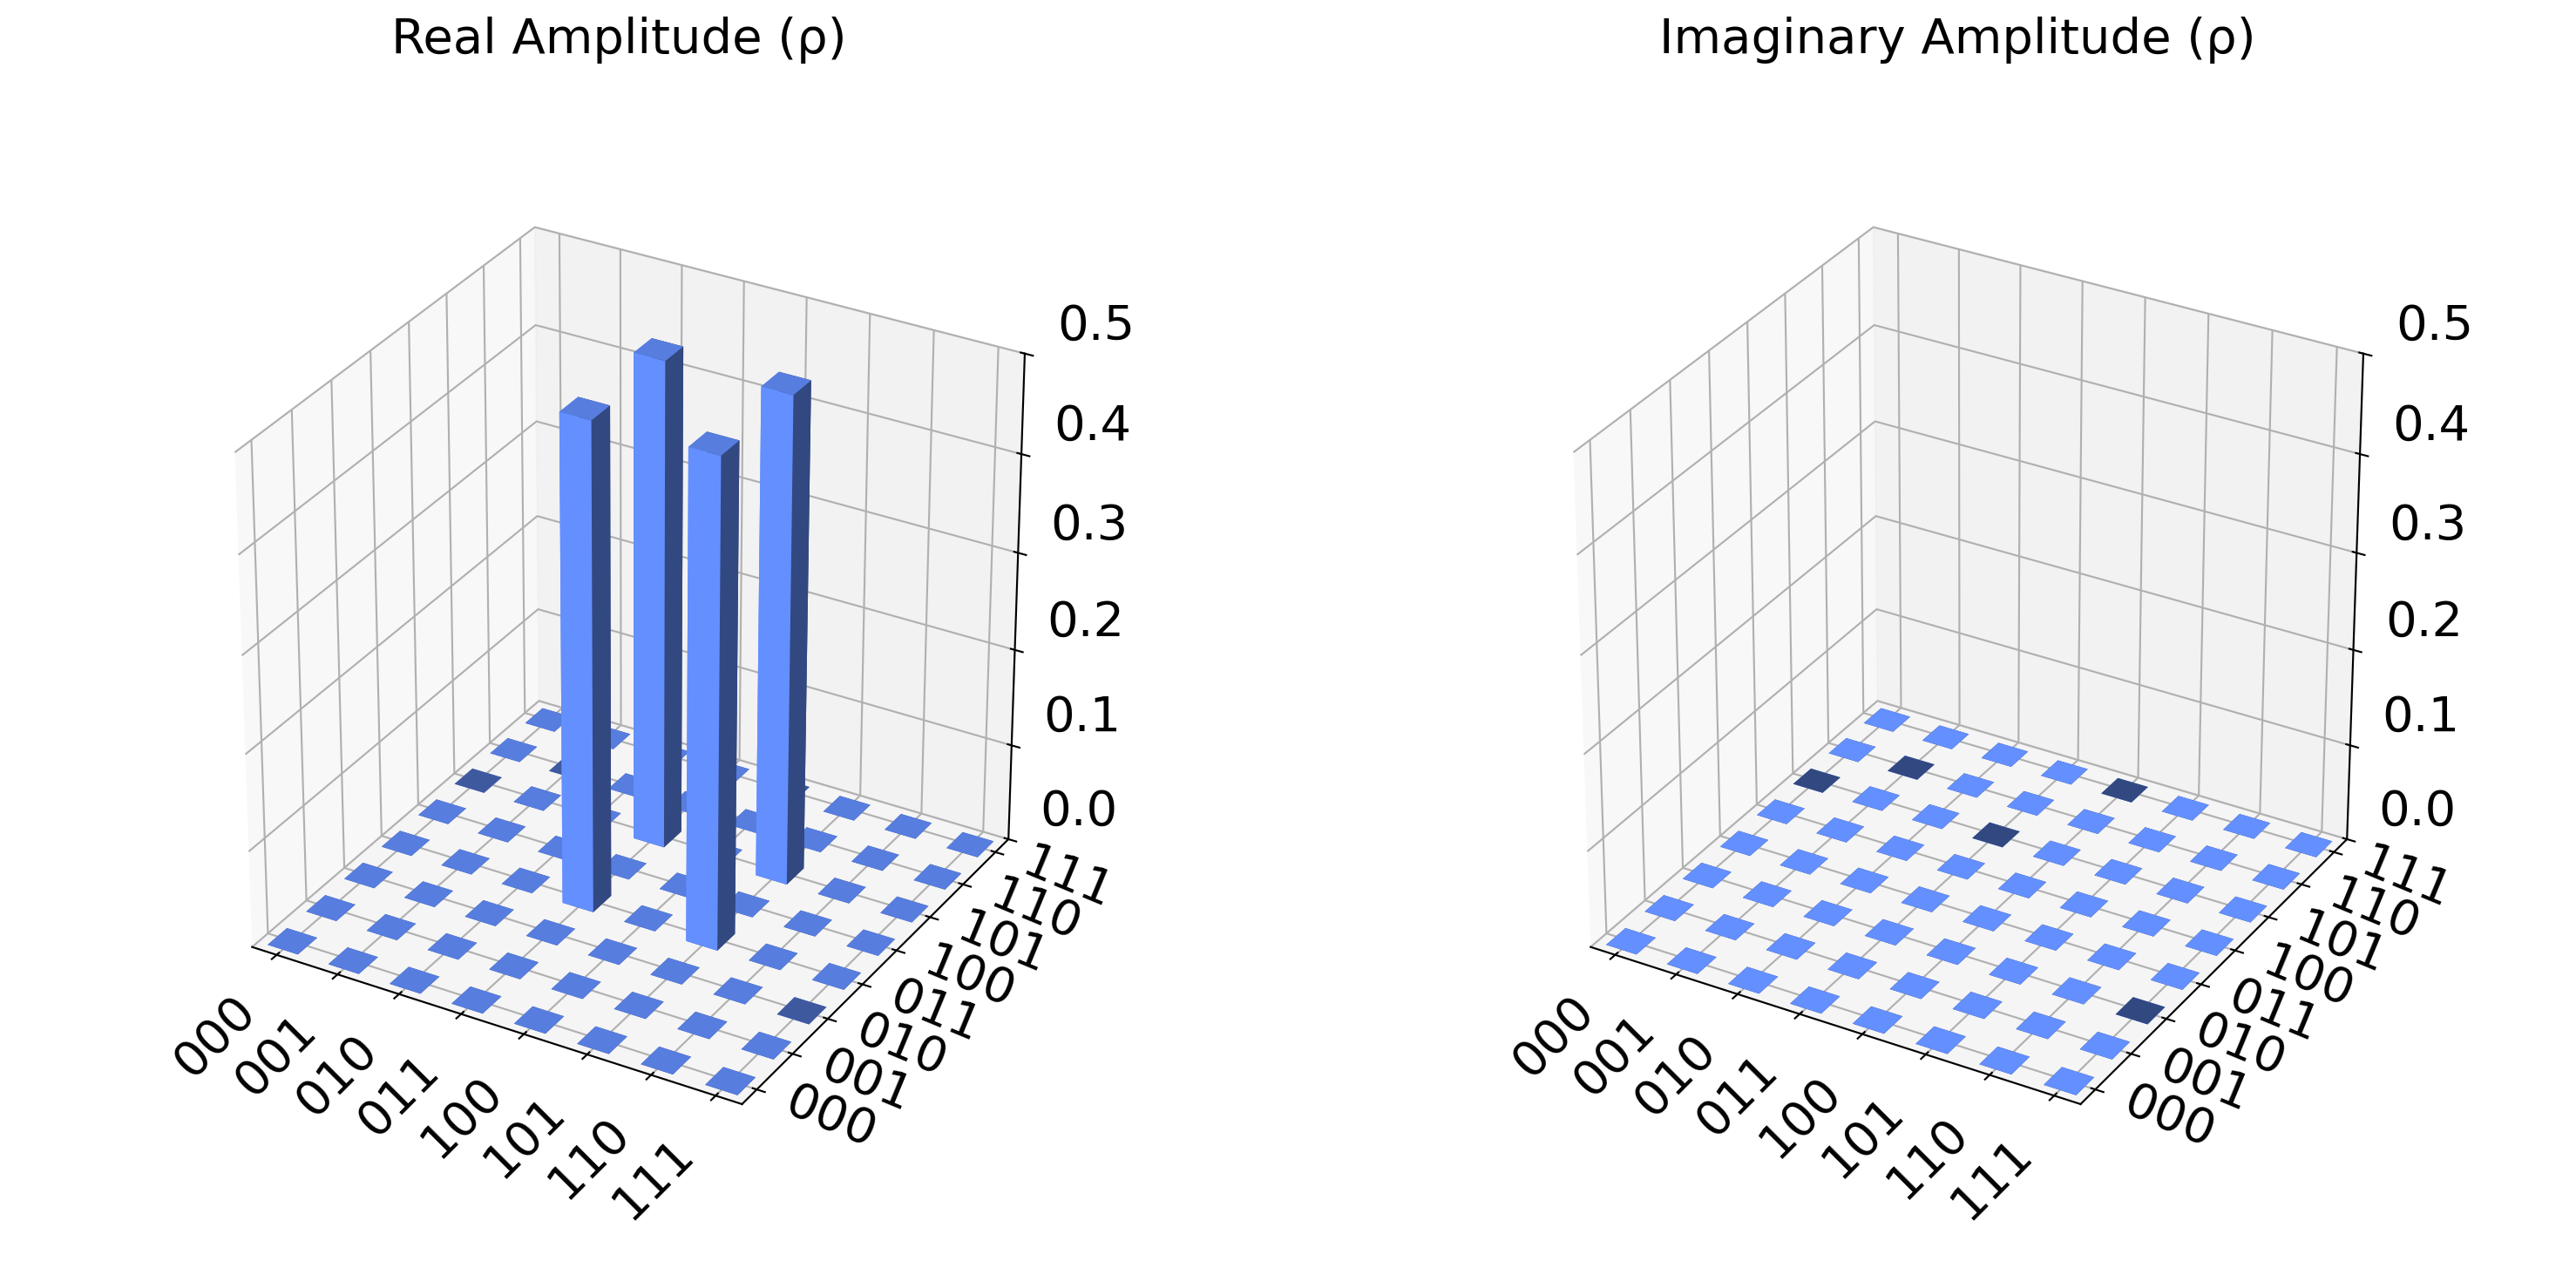

In [9]:
circuit.cx(qreg_q[0], qreg_q[1])

state5 = Statevector.from_instruction(circuit)
print(state5)

# Visualização "City" - mostra a matriz densidade
print("\n🏙️ State City (visualização 3D da matriz densidade):")
plot_state_city(state5)

Statevector([ 0. +0.j,  0. +0.j,  0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j,
              0. +0.j,  0. +0.j],
            dims=(2, 2, 2))

🌐 Q-Sphere - Estado completo antes da medição:


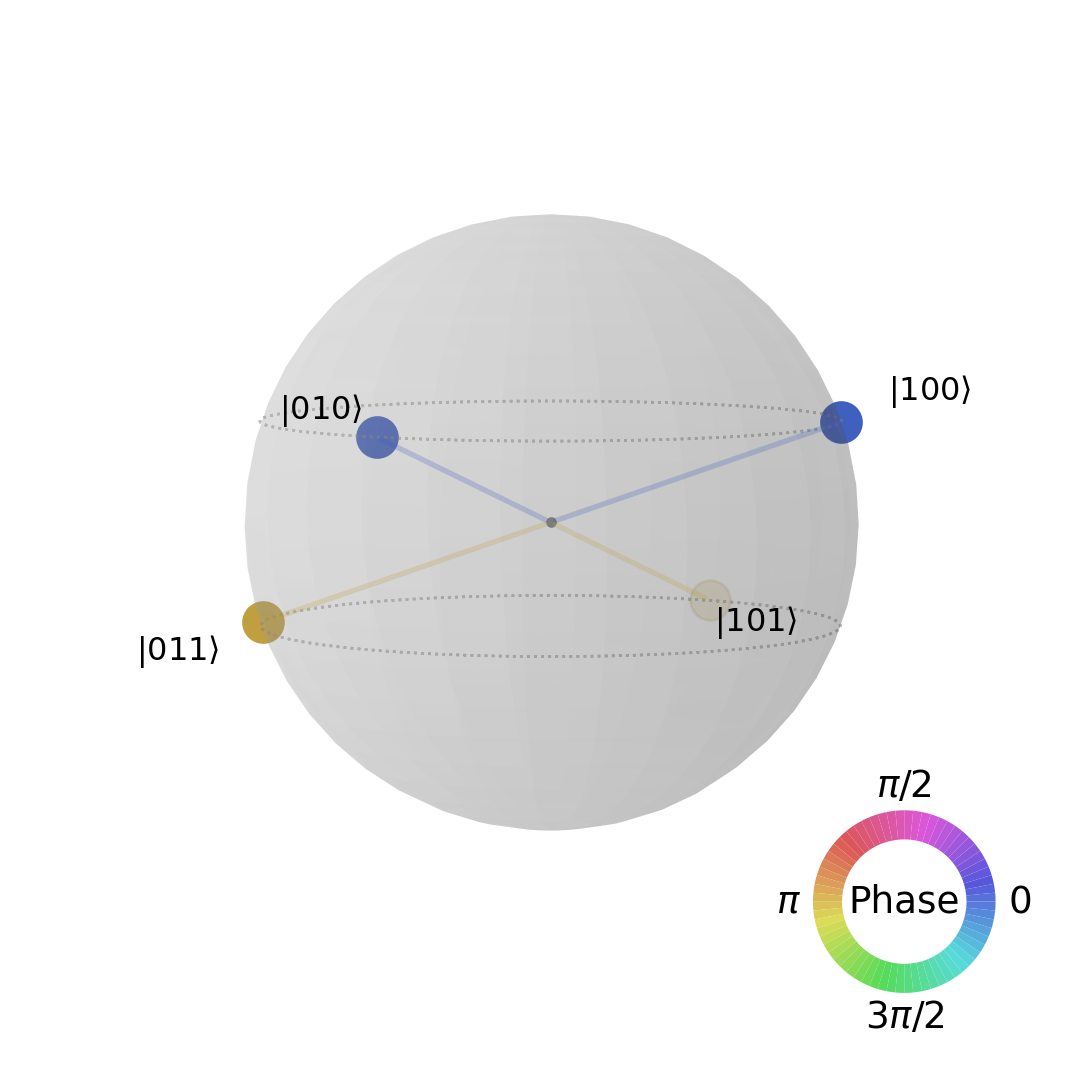

In [10]:
circuit.h(qreg_q[0])
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2])
circuit.draw('mpl')

state6 = Statevector.from_instruction(circuit)
print(state6)

# Visualização combinada para o estado mais complexo
print("\n🌐 Q-Sphere - Estado completo antes da medição:")
plot_state_qsphere(state6)

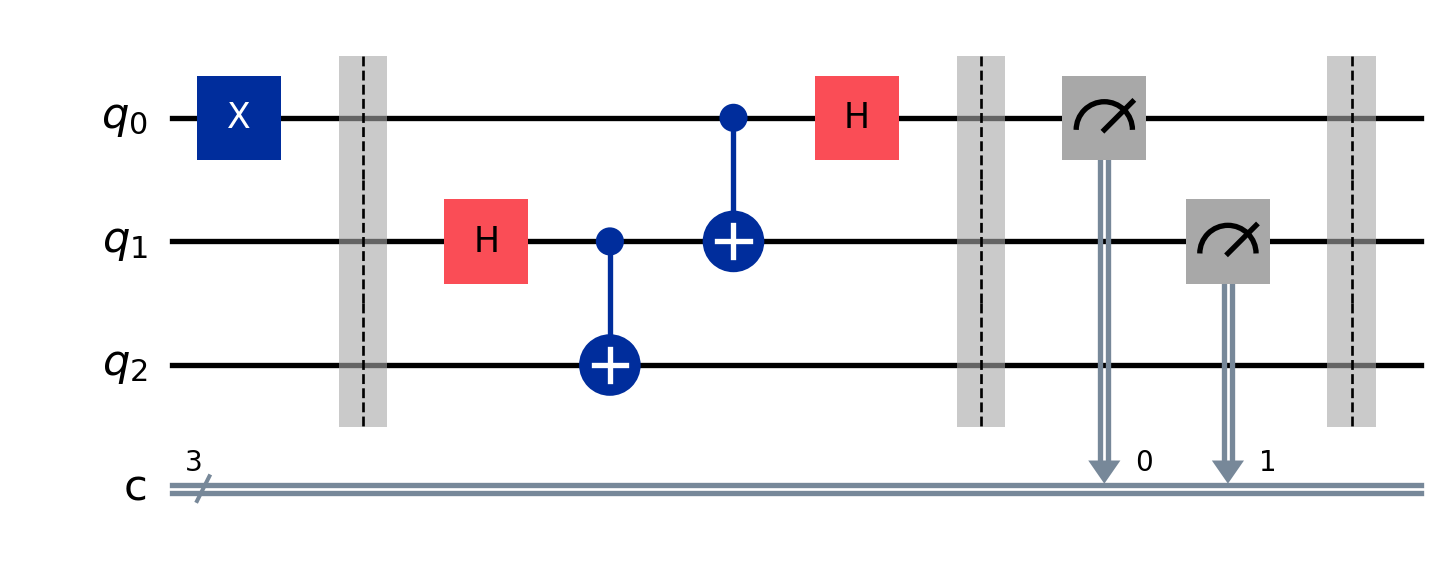

In [11]:
circuit.measure(qreg_q[0], creg_c[0])
circuit.measure(qreg_q[1], creg_c[1])
circuit.barrier(qreg_q[0], qreg_q[1], qreg_q[2])
circuit.draw('mpl')

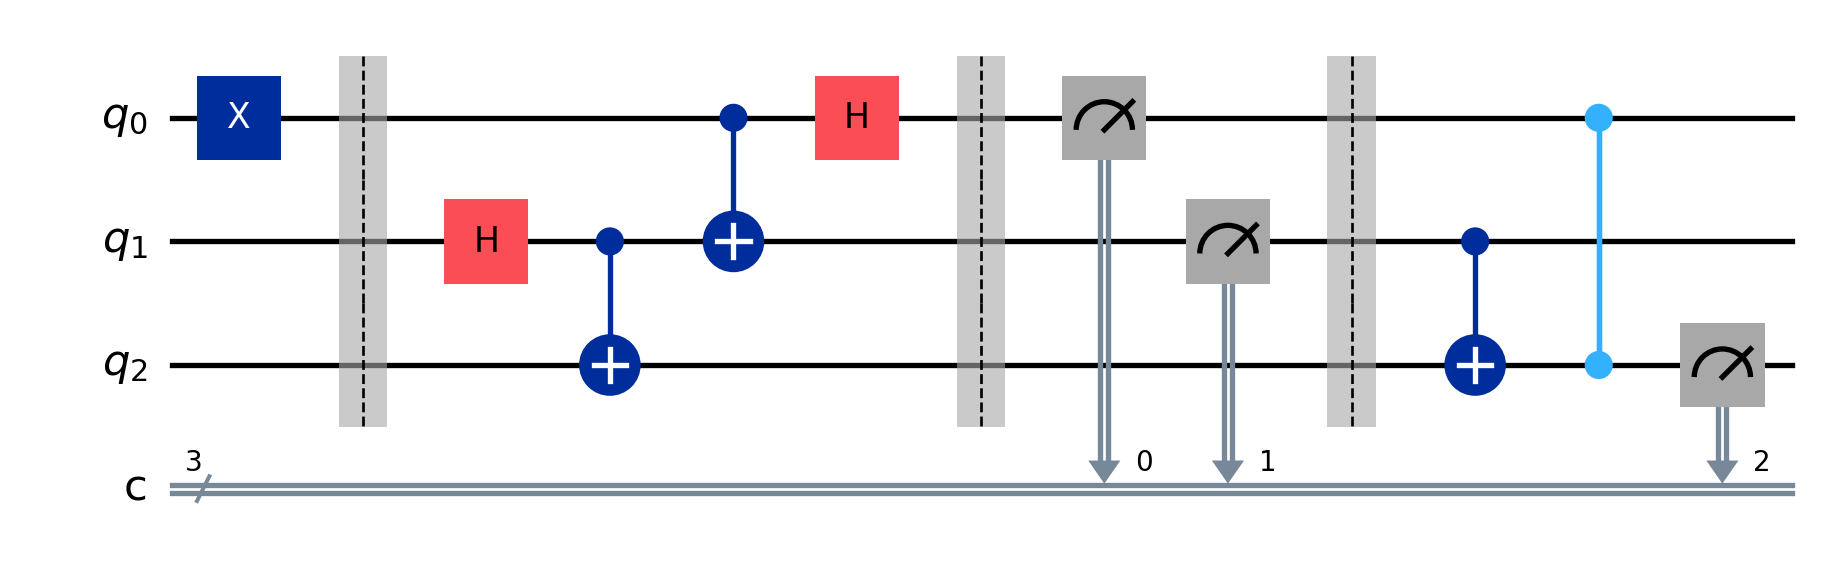

In [12]:
# Aplicar as correções de Bob e fazer a medição final
circuit.cx(qreg_q[1], qreg_q[2])  # Correção X condicional
circuit.cz(qreg_q[0], qreg_q[2])  # Correção Z condicional
circuit.measure(qreg_q[2], creg_c[2])  # Medir o qubit de Bob
circuit.draw('mpl')

In [13]:
import numpy as np
from qiskit.quantum_info import Statevector, Operator

# Estados de Bob após medição de Alice (da tabela do Passo 4)
cenarios = [
    ("00", np.array([0, -1])),      # -|1⟩
    ("01", np.array([1, 0])),       # |0⟩
    ("10", np.array([0, -1])),      # -|1⟩
    ("11", np.array([-1, 0]))       # -|0⟩
]

print("🔬 Simulando os 4 cenários de teletransporte:\n")
print("="*70)

# Definir as portas
X = Operator([[0, 1], [1, 0]])
Z = Operator([[1, 0], [0, -1]])

for medicao, estado_bob in cenarios:
    c0, c1 = int(medicao[0]), int(medicao[1])
    
    # Estado inicial de Bob neste cenário
    bob = Statevector(estado_bob)
    print(f"\n📊 Cenário: Alice mediu |{medicao}⟩")
    print(f"   Estado de Bob ANTES das correções: {bob.data}")
    
    # Aplicar correções de Bob (ordem: X depois Z)
    # CNOT(c[1], Bob) = X se c[1]=1
    if c1 == 1:
        bob = bob.evolve(X)
        print(f"   → Aplicou X (porque c[1]=1): {bob.data}")
    
    # CZ(c[0], Bob) = Z se c[0]=1  
    if c0 == 1:
        bob = bob.evolve(Z)
        print(f"   → Aplicou Z (porque c[0]=1): {bob.data}")
    
    # Resultado final
    print(f"   ✅ Estado FINAL de Bob: {bob.data}")
    
    # Verificar se é |1⟩ (ignorando fase global)
    esperado = np.array([0, 1])
    if np.allclose(np.abs(bob.data), np.abs(esperado)):
        print(f"   🎉 SUCESSO! Bob recebeu |1⟩")
    else:
        print(f"   ❌ ERRO! Estado inesperado")

print("\n" + "="*70)
print("✨ Conclusão: Em TODOS os 4 cenários, Bob recupera |1⟩!")
print("   O teletransporte quântico funcionou perfeitamente! 🚀")

🔬 Simulando os 4 cenários de teletransporte:


📊 Cenário: Alice mediu |00⟩
   Estado de Bob ANTES das correções: [ 0.+0.j -1.+0.j]
   ✅ Estado FINAL de Bob: [ 0.+0.j -1.+0.j]
   🎉 SUCESSO! Bob recebeu |1⟩

📊 Cenário: Alice mediu |01⟩
   Estado de Bob ANTES das correções: [1.+0.j 0.+0.j]
   → Aplicou X (porque c[1]=1): [0.+0.j 1.+0.j]
   ✅ Estado FINAL de Bob: [0.+0.j 1.+0.j]
   🎉 SUCESSO! Bob recebeu |1⟩

📊 Cenário: Alice mediu |10⟩
   Estado de Bob ANTES das correções: [ 0.+0.j -1.+0.j]
   → Aplicou Z (porque c[0]=1): [0.+0.j 1.+0.j]
   ✅ Estado FINAL de Bob: [0.+0.j 1.+0.j]
   🎉 SUCESSO! Bob recebeu |1⟩

📊 Cenário: Alice mediu |11⟩
   Estado de Bob ANTES das correções: [-1.+0.j  0.+0.j]
   → Aplicou X (porque c[1]=1): [ 0.+0.j -1.+0.j]
   → Aplicou Z (porque c[0]=1): [0.+0.j 1.+0.j]
   ✅ Estado FINAL de Bob: [0.+0.j 1.+0.j]
   🎉 SUCESSO! Bob recebeu |1⟩

✨ Conclusão: Em TODOS os 4 cenários, Bob recupera |1⟩!
   O teletransporte quântico funcionou perfeitamente! 🚀


In [14]:
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Criar circuito (começando vazio)
final_circuit = QuantumCircuit(3)

Estado: |000⟩ (todos qubits em |0⟩)
Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


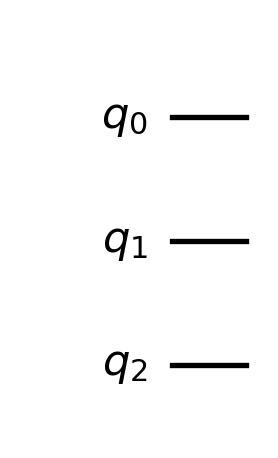

In [15]:
# Visualizar estado inicial (circuito vazio)
state_0 = Statevector.from_instruction(final_circuit)
print("Estado: |000⟩ (todos qubits em |0⟩)")
print(state_0)
final_circuit.draw('mpl')

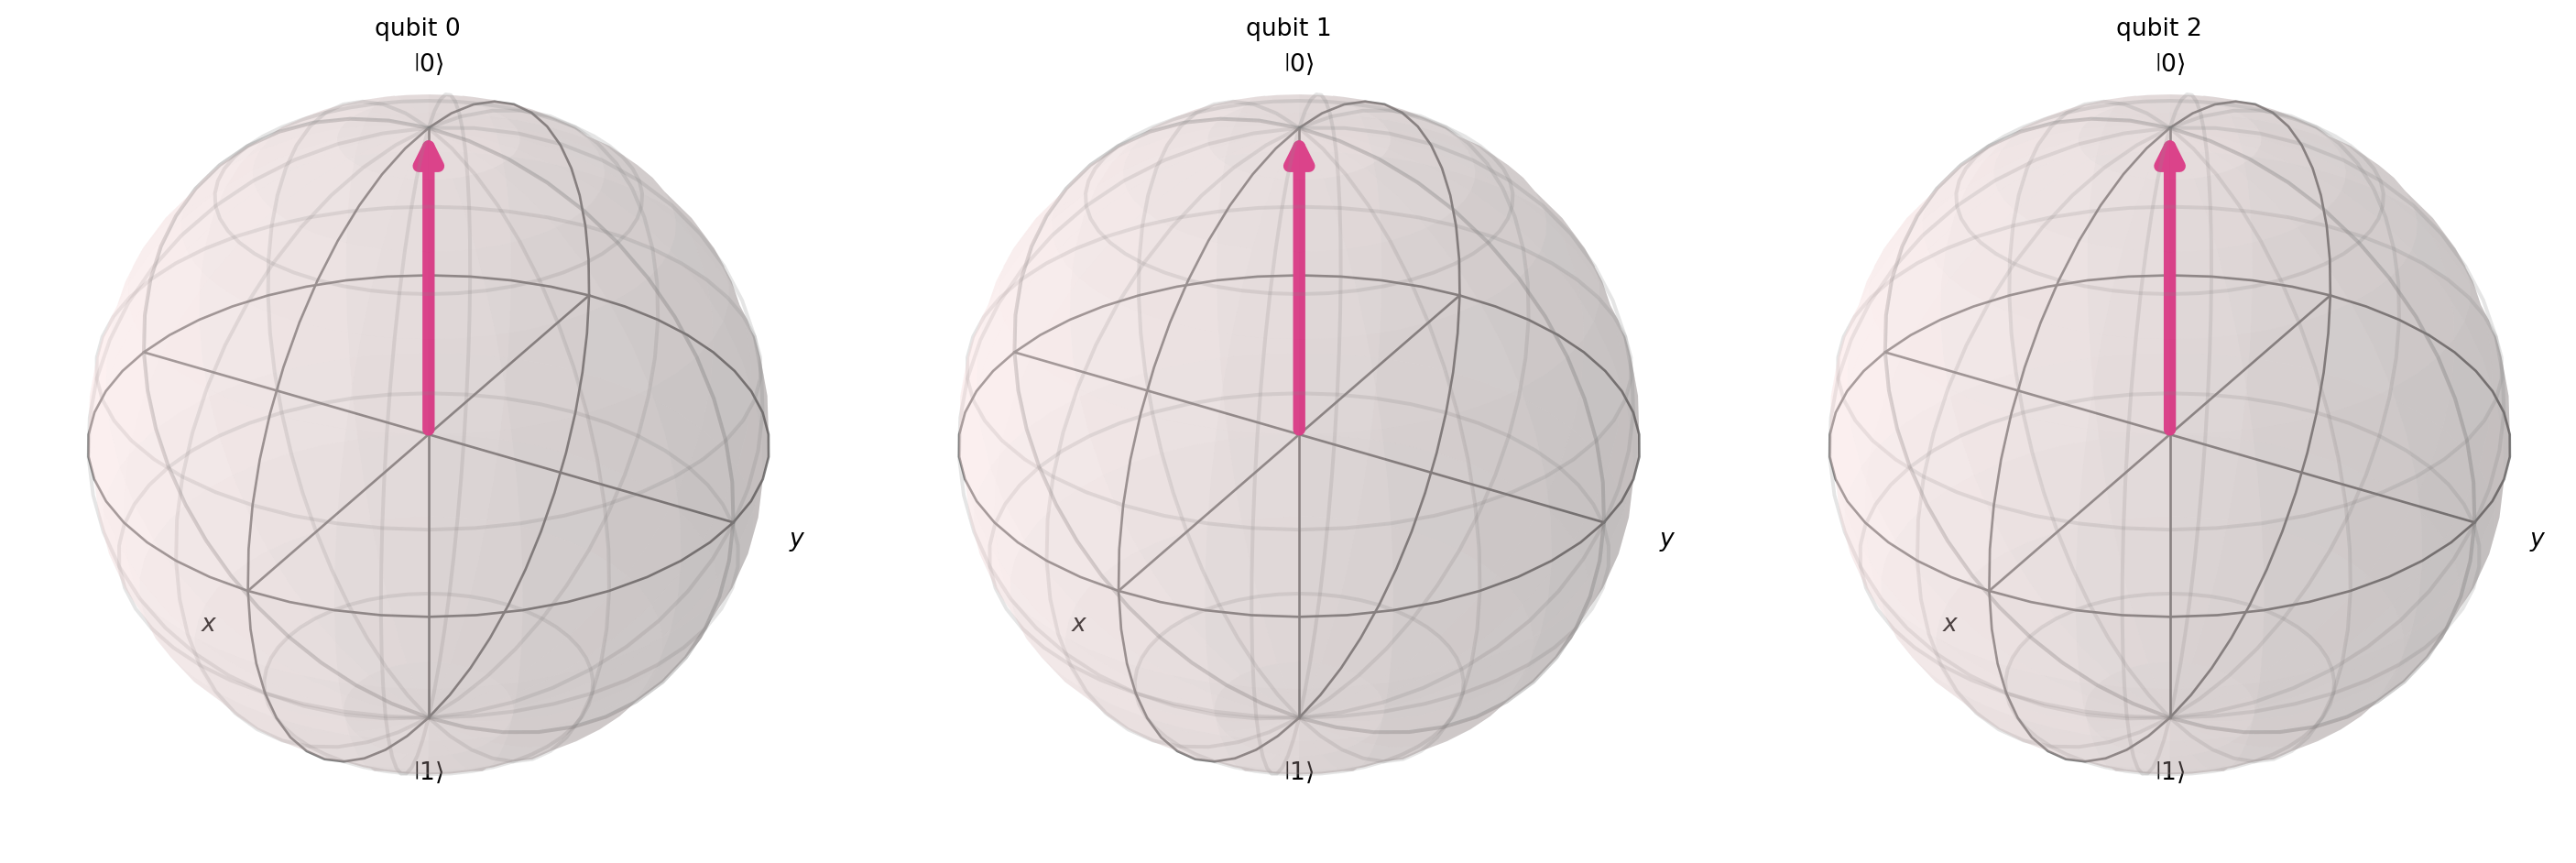

In [16]:
plot_bloch_multivector(state_0)

Estado: |100⟩ (qubit 0 preparado em |1⟩)
Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


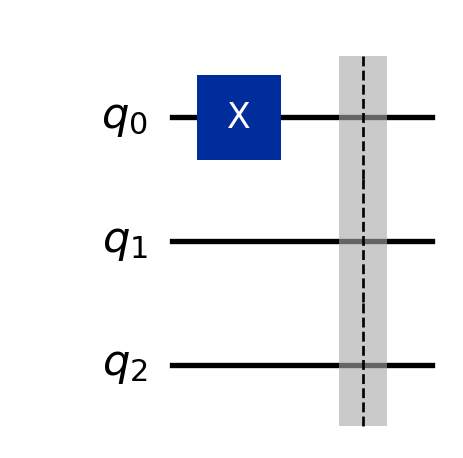

In [17]:
# Aplicar X no qubit 0 (preparar |1⟩)
final_circuit.x(0)
final_circuit.barrier()

# Visualizar estado após X
state_1 = Statevector.from_instruction(final_circuit)
print("Estado: |100⟩ (qubit 0 preparado em |1⟩)")
print(state_1)
final_circuit.draw('mpl')

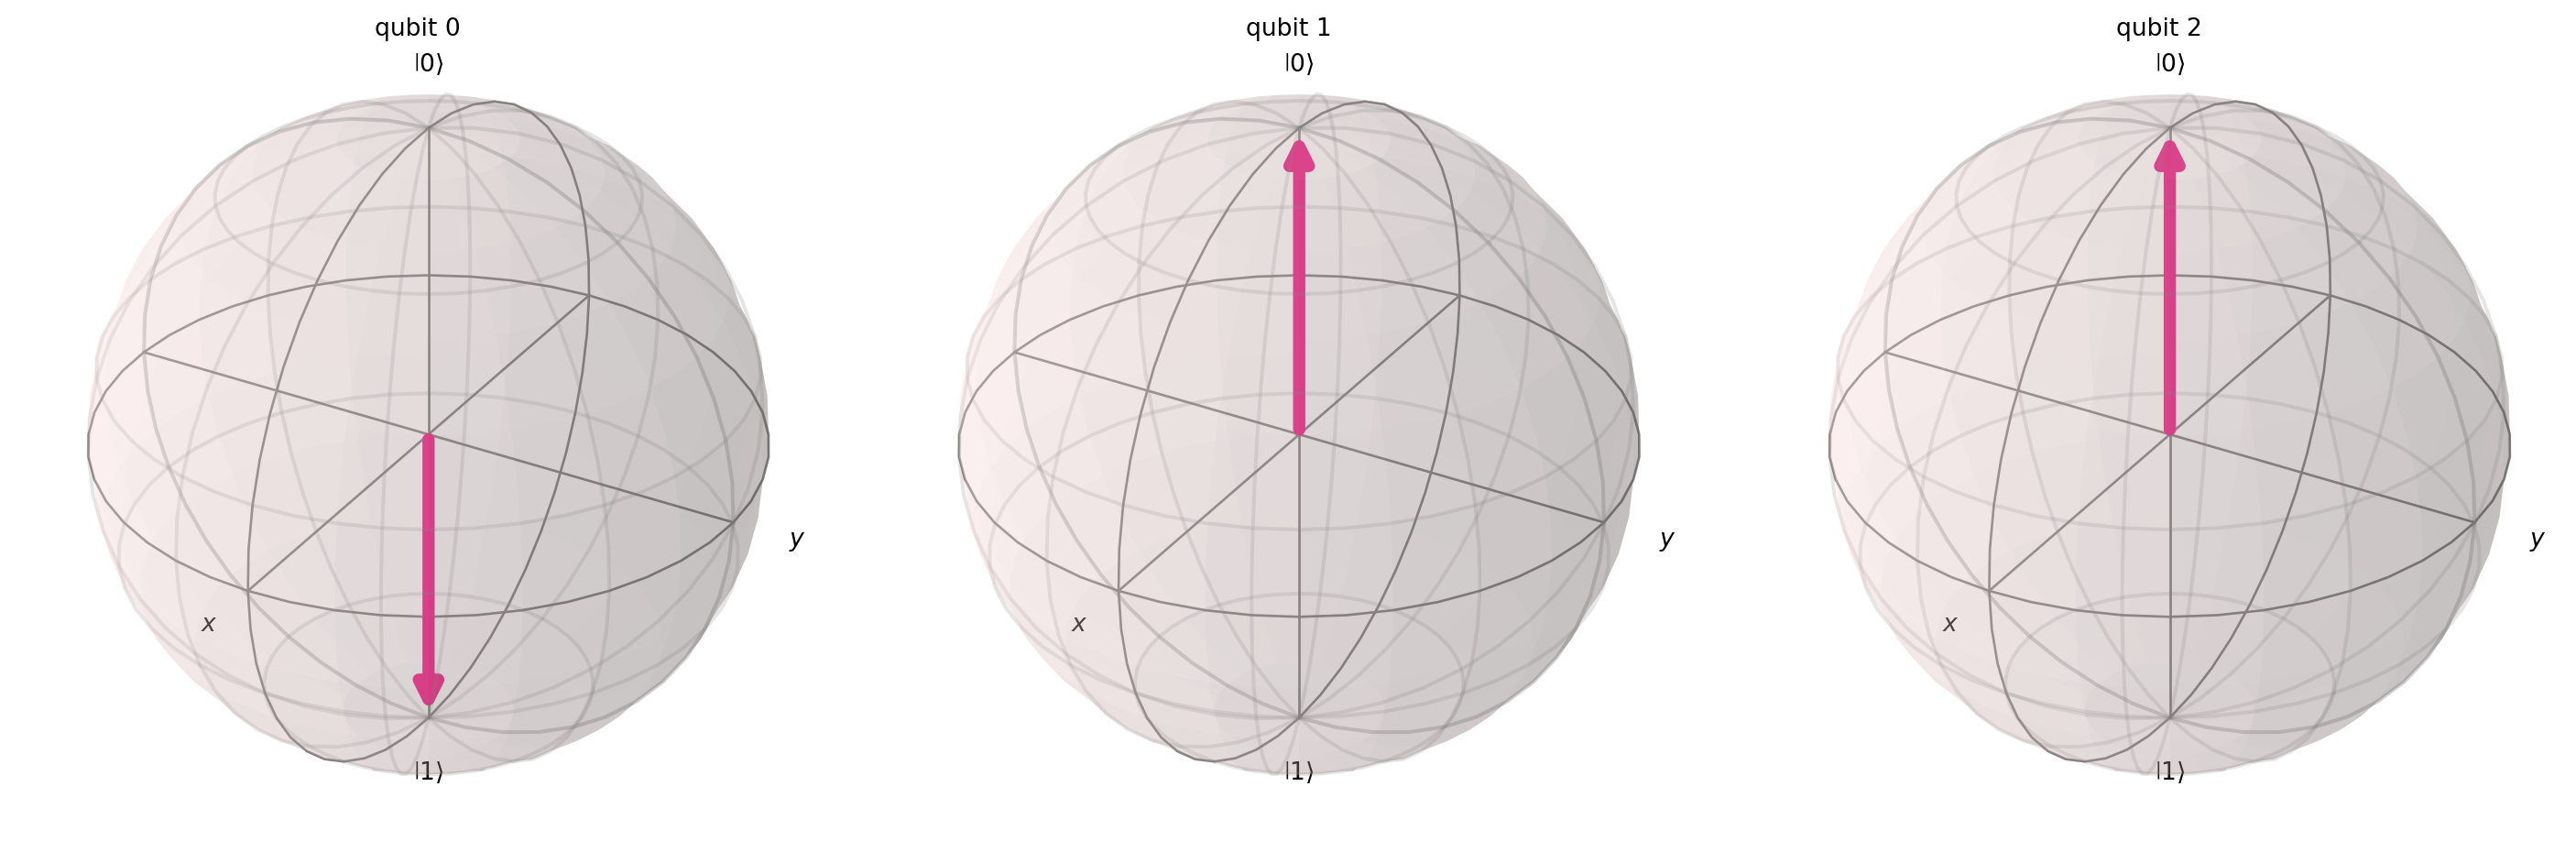

In [18]:
plot_bloch_multivector(state_1)

Estado: 1/√2(|100⟩ + |111⟩) - qubits 1 e 2 emaranhados
Statevector([0.        +0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


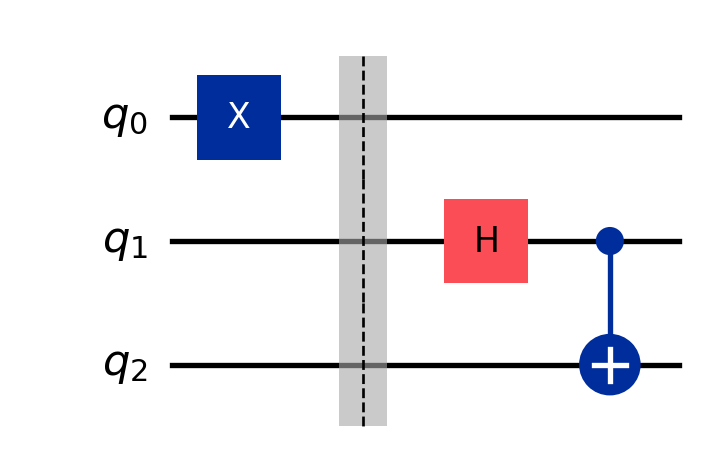

In [19]:
# Criar par de Bell entre qubits 1 e 2
final_circuit.h(1)
final_circuit.cx(1, 2)

# Visualizar estado após criar par de Bell
state_2 = Statevector.from_instruction(final_circuit)
print("Estado: 1/√2(|100⟩ + |111⟩) - qubits 1 e 2 emaranhados")
print(state_2)
final_circuit.draw('mpl')


🌐 Q-Sphere - Visualizando o emaranhamento:


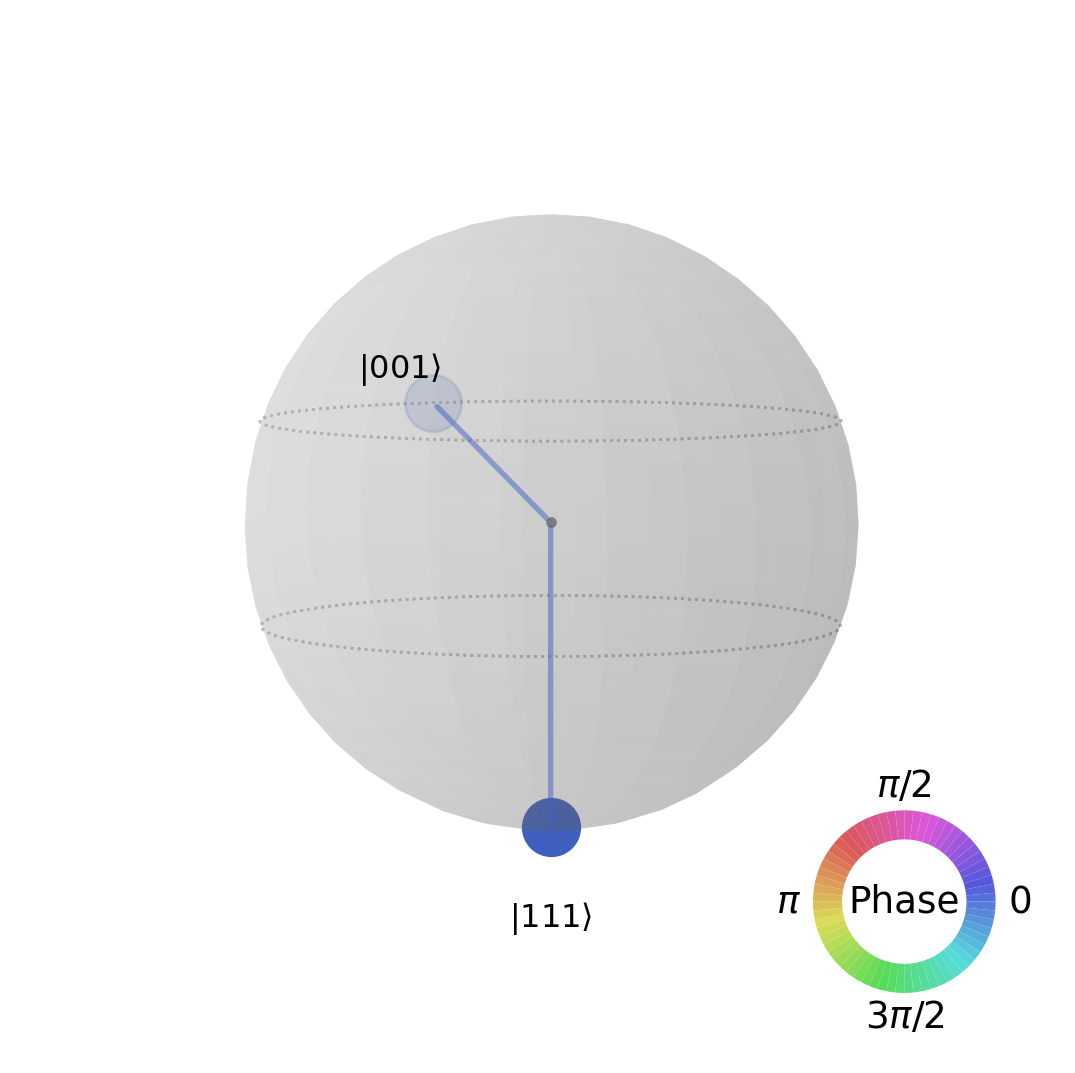

In [20]:
print("\n🌐 Q-Sphere - Visualizando o emaranhamento:")
plot_state_qsphere(state_2)

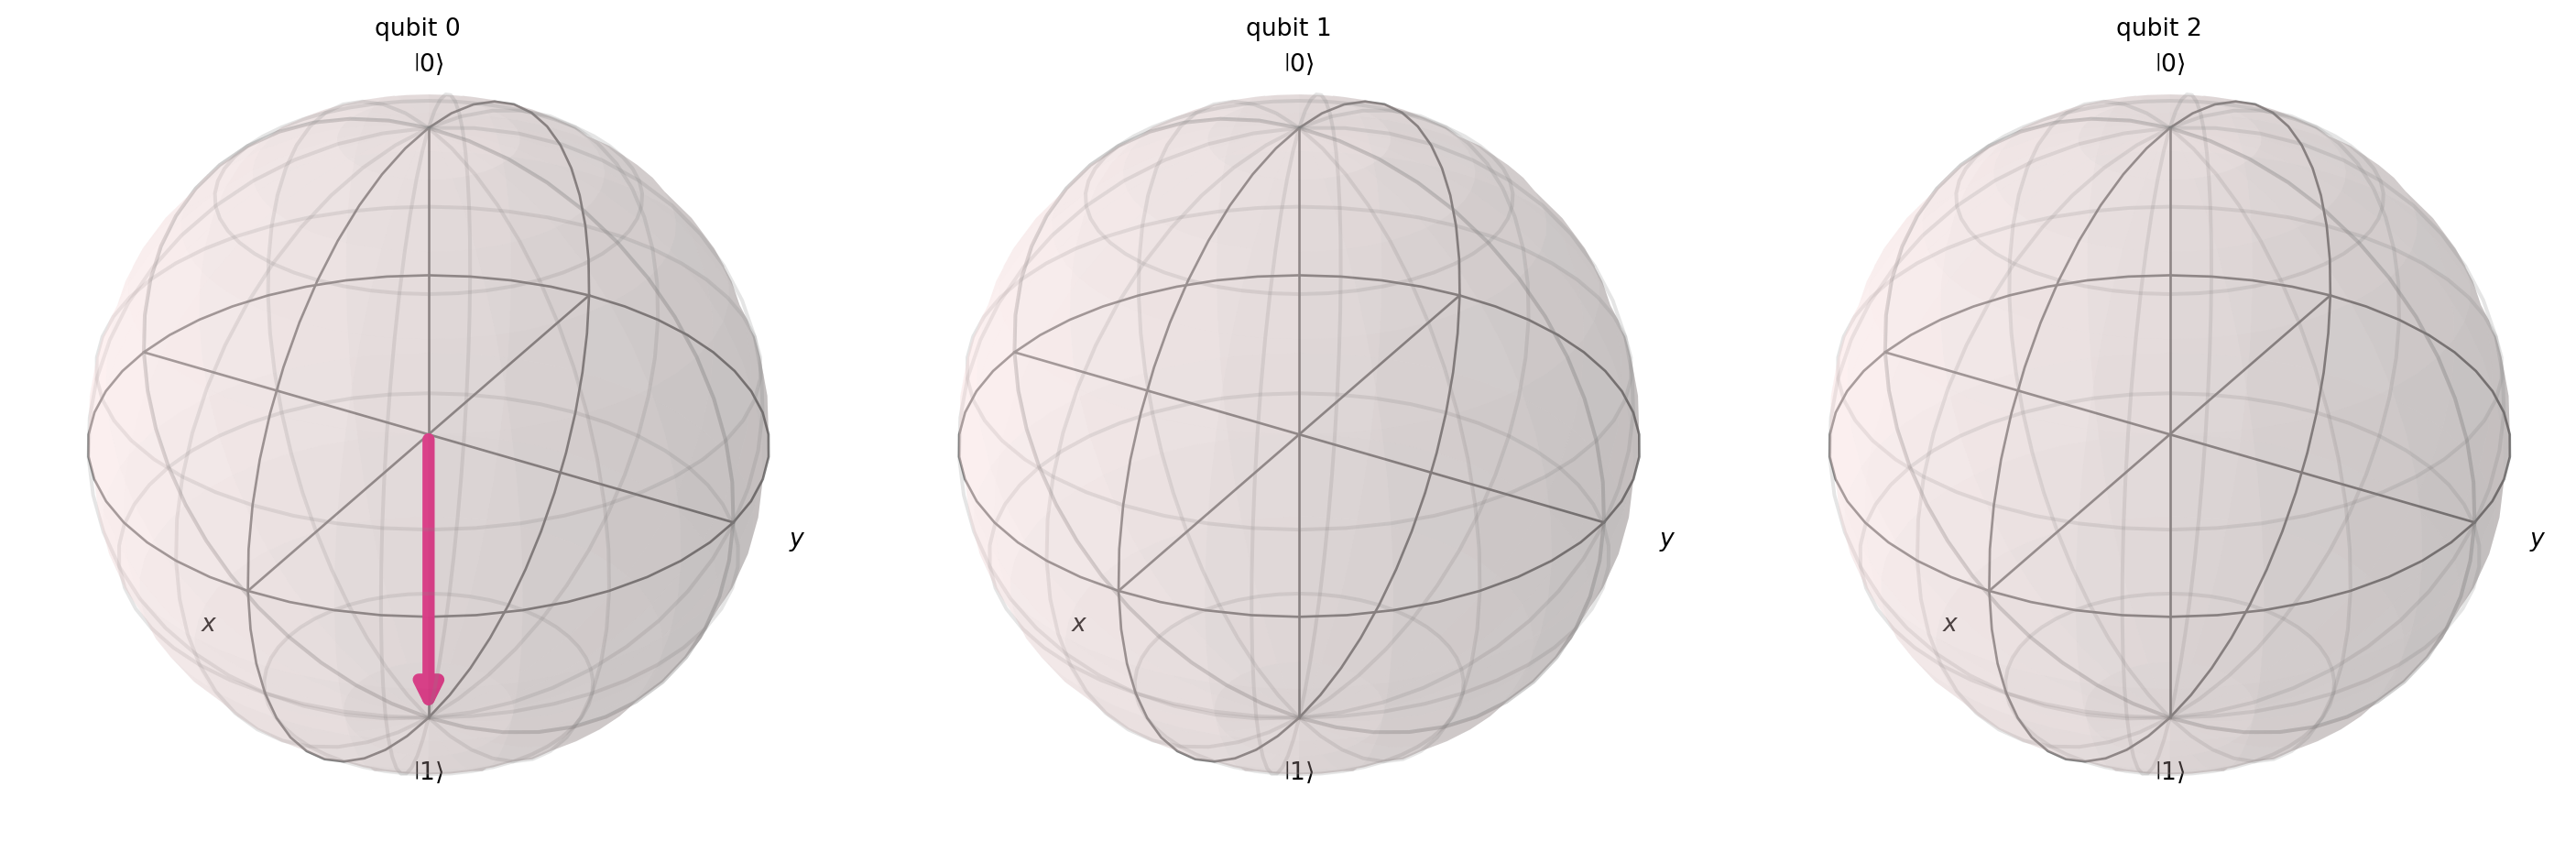

In [21]:
plot_bloch_multivector(state_2)

Estado: 1/2(|010⟩ - |110⟩ + |001⟩ - |101⟩) - 3 qubits emaranhados
Statevector([ 0. +0.j,  0. +0.j,  0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j,
              0. +0.j,  0. +0.j],
            dims=(2, 2, 2))


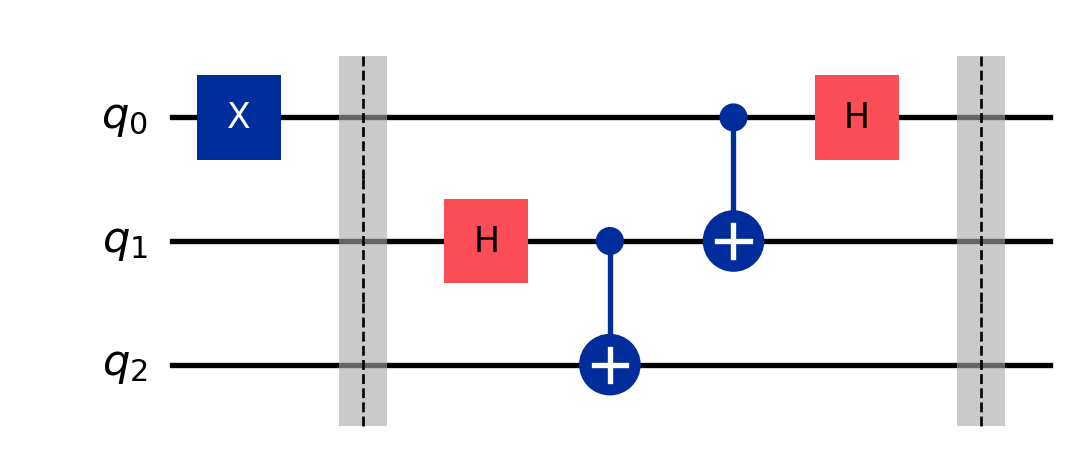

In [22]:
# Aplicar medição de Bell (sem as medições clássicas)
final_circuit.cx(0, 1)
final_circuit.h(0)
final_circuit.barrier()

# Visualizar estado após medição de Bell
state_3 = Statevector.from_instruction(final_circuit)
print("Estado: 1/2(|010⟩ - |110⟩ + |001⟩ - |101⟩) - 3 qubits emaranhados")
print(state_3)
final_circuit.draw('mpl')


🌐 Q-Sphere - Superposição dos 4 cenários possíveis:


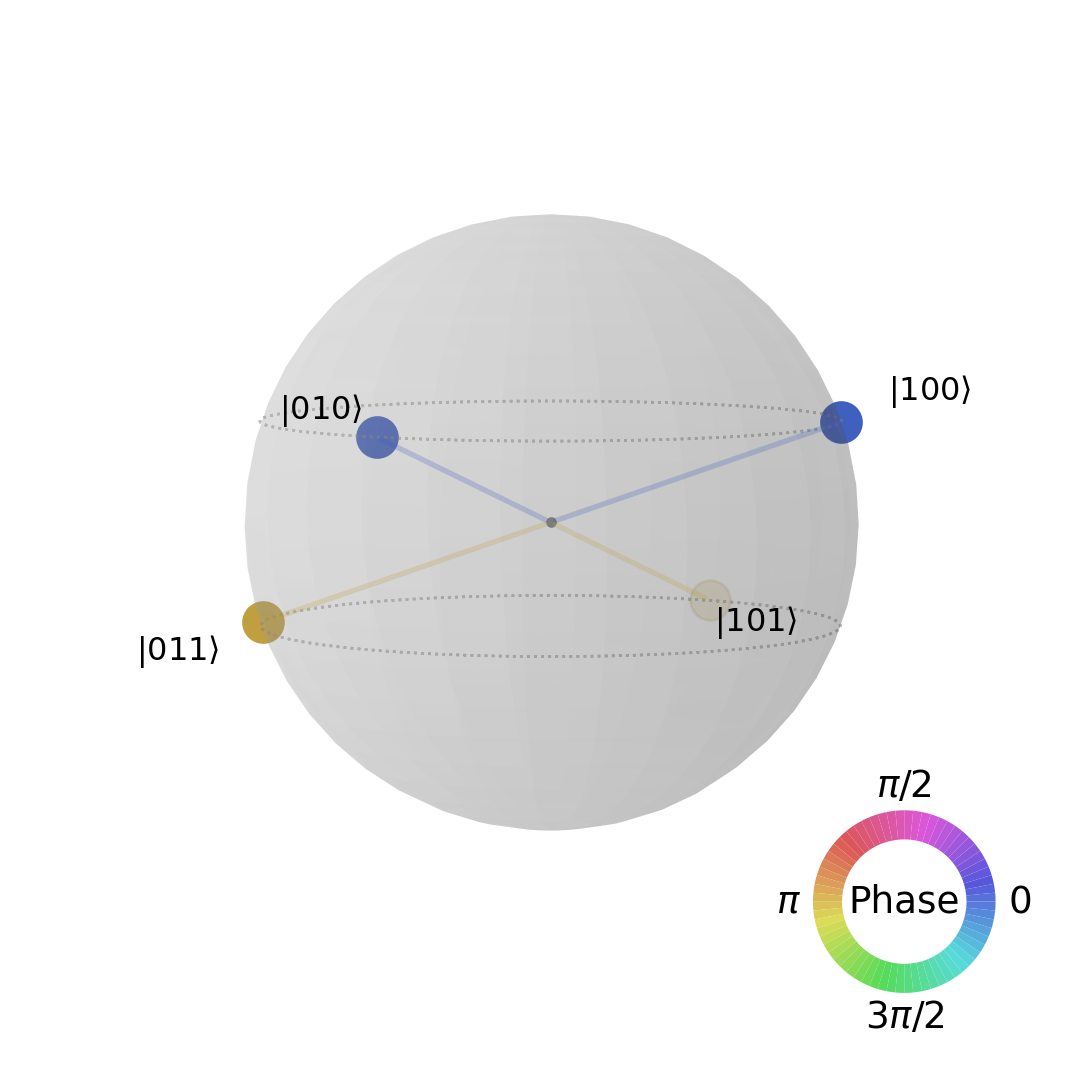

In [23]:
print("\n🌐 Q-Sphere - Superposição dos 4 cenários possíveis:")
plot_state_qsphere(state_3)

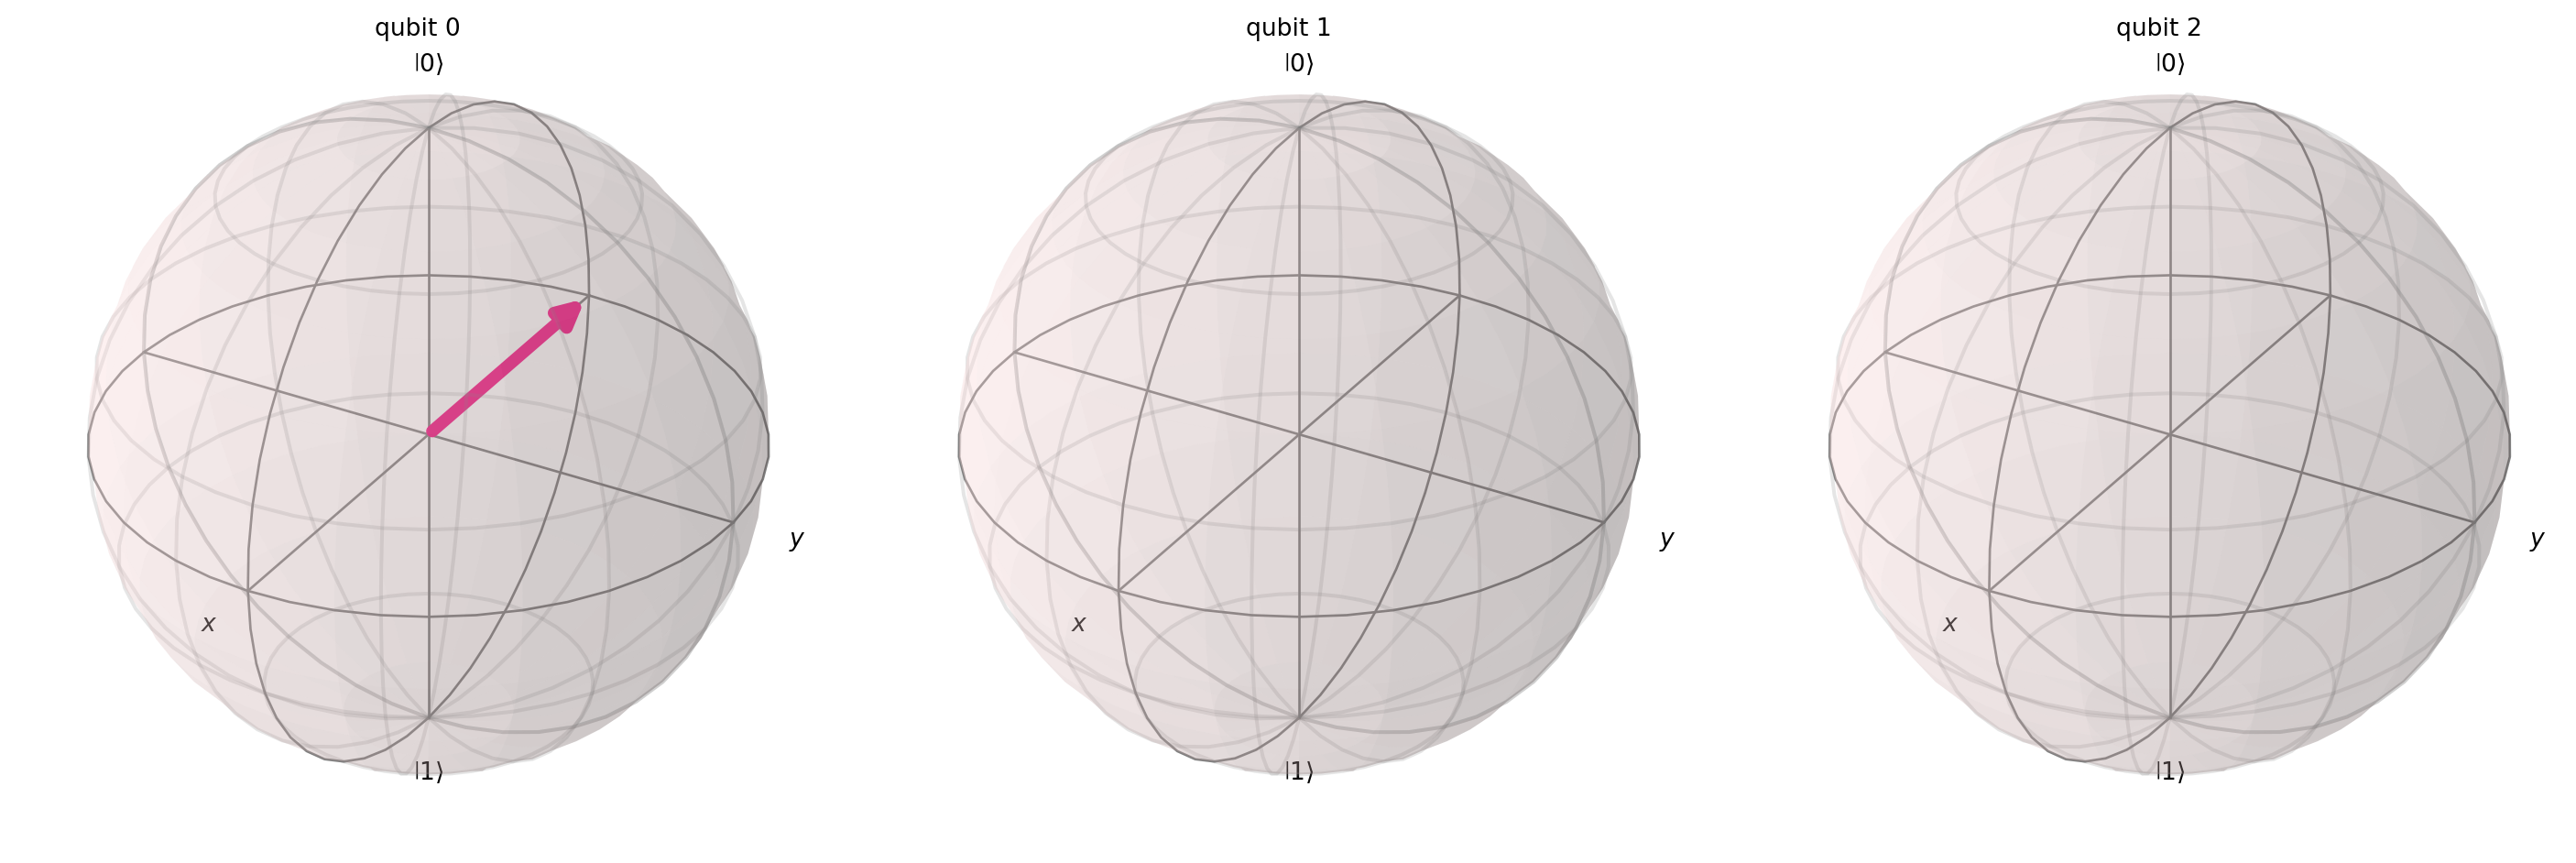

In [24]:
plot_bloch_multivector(state_3)

Estado completo antes das correções:
Statevector([ 0. +0.j,  0. +0.j,  0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j,
              0. +0.j,  0. +0.j],
            dims=(2, 2, 2))

Este estado representa os 4 cenários possíveis com igual probabilidade (25% cada)


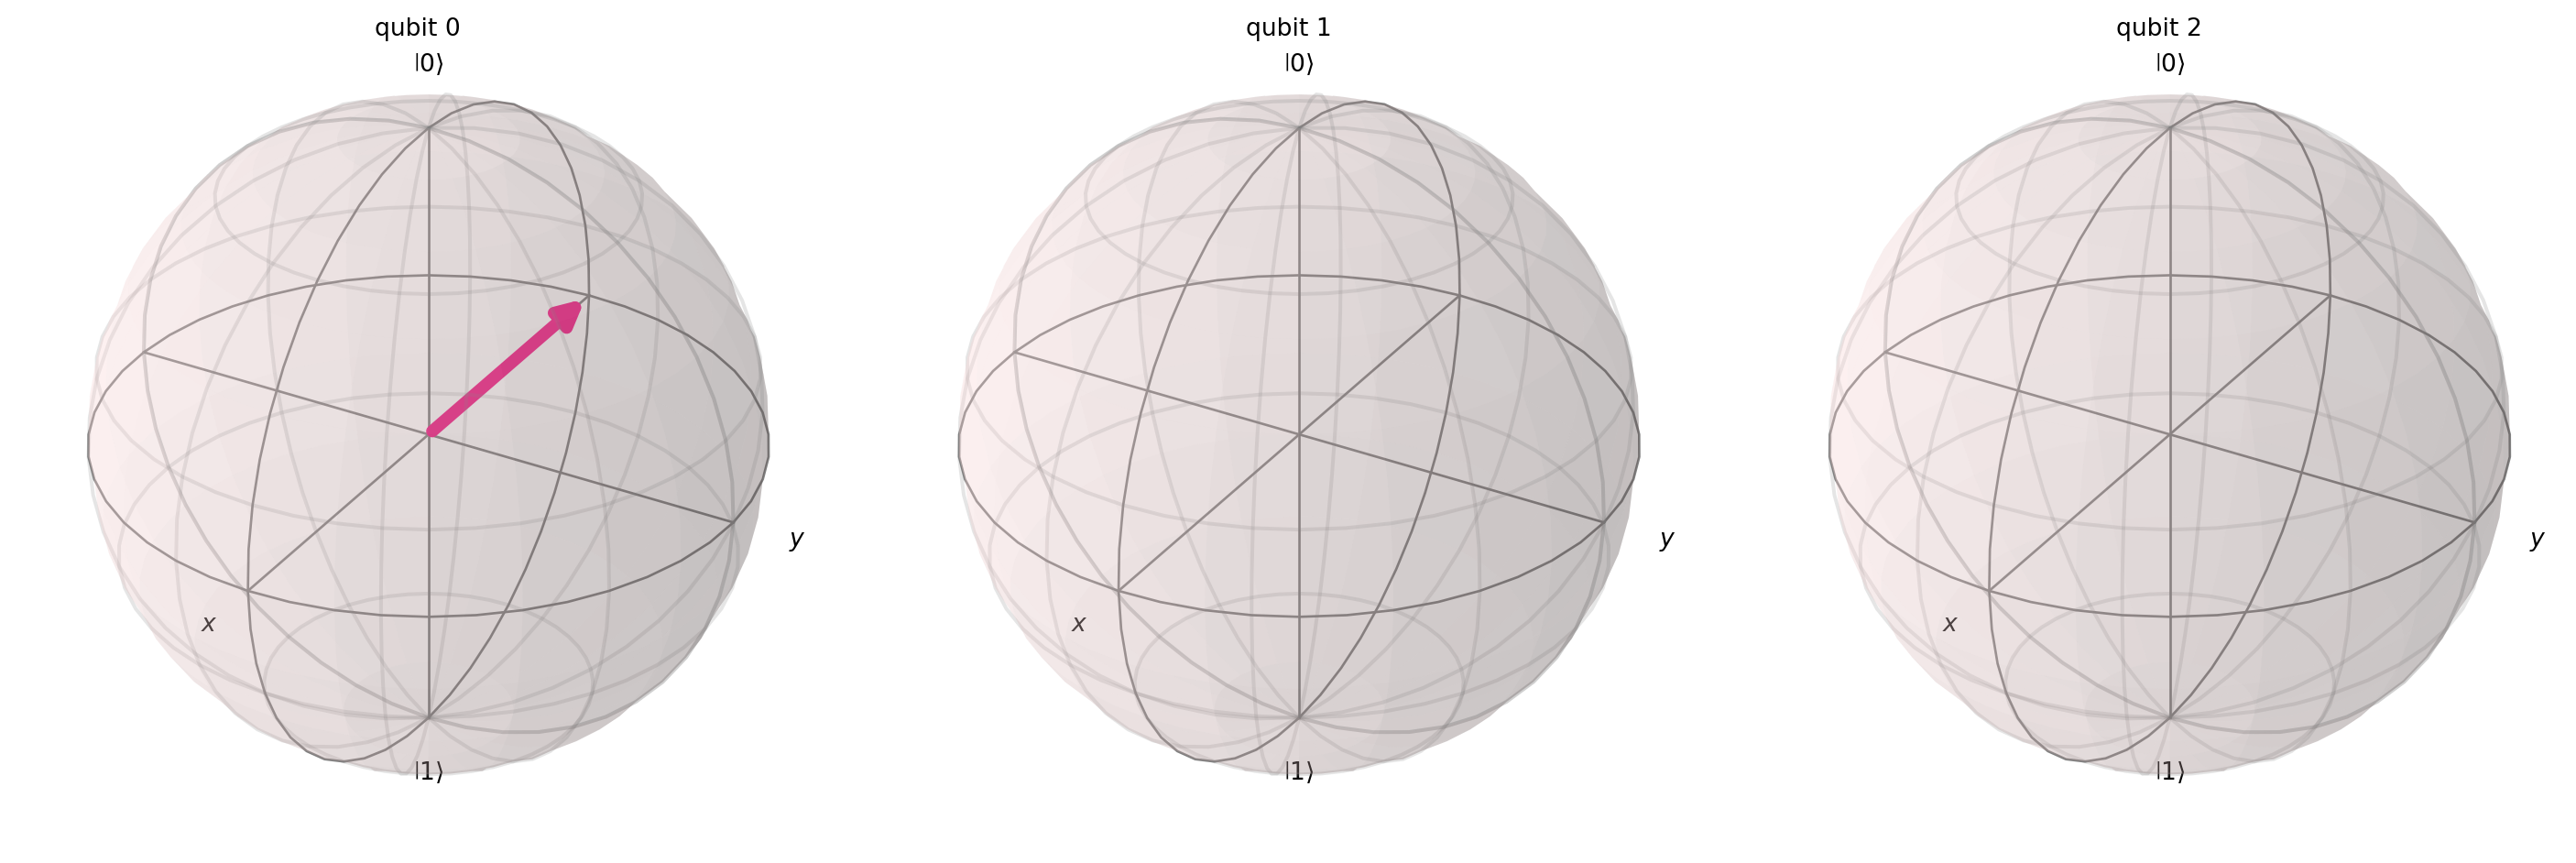

In [25]:
# Estado completo antes das correções de Bob
state_final = Statevector.from_instruction(final_circuit)
print("Estado completo antes das correções:")
print(state_final)
print("\nEste estado representa os 4 cenários possíveis com igual probabilidade (25% cada)")

# Bloch sphere
plot_bloch_multivector(state_final)


🏙️ State City - Estrutura completa do estado emaranhado:


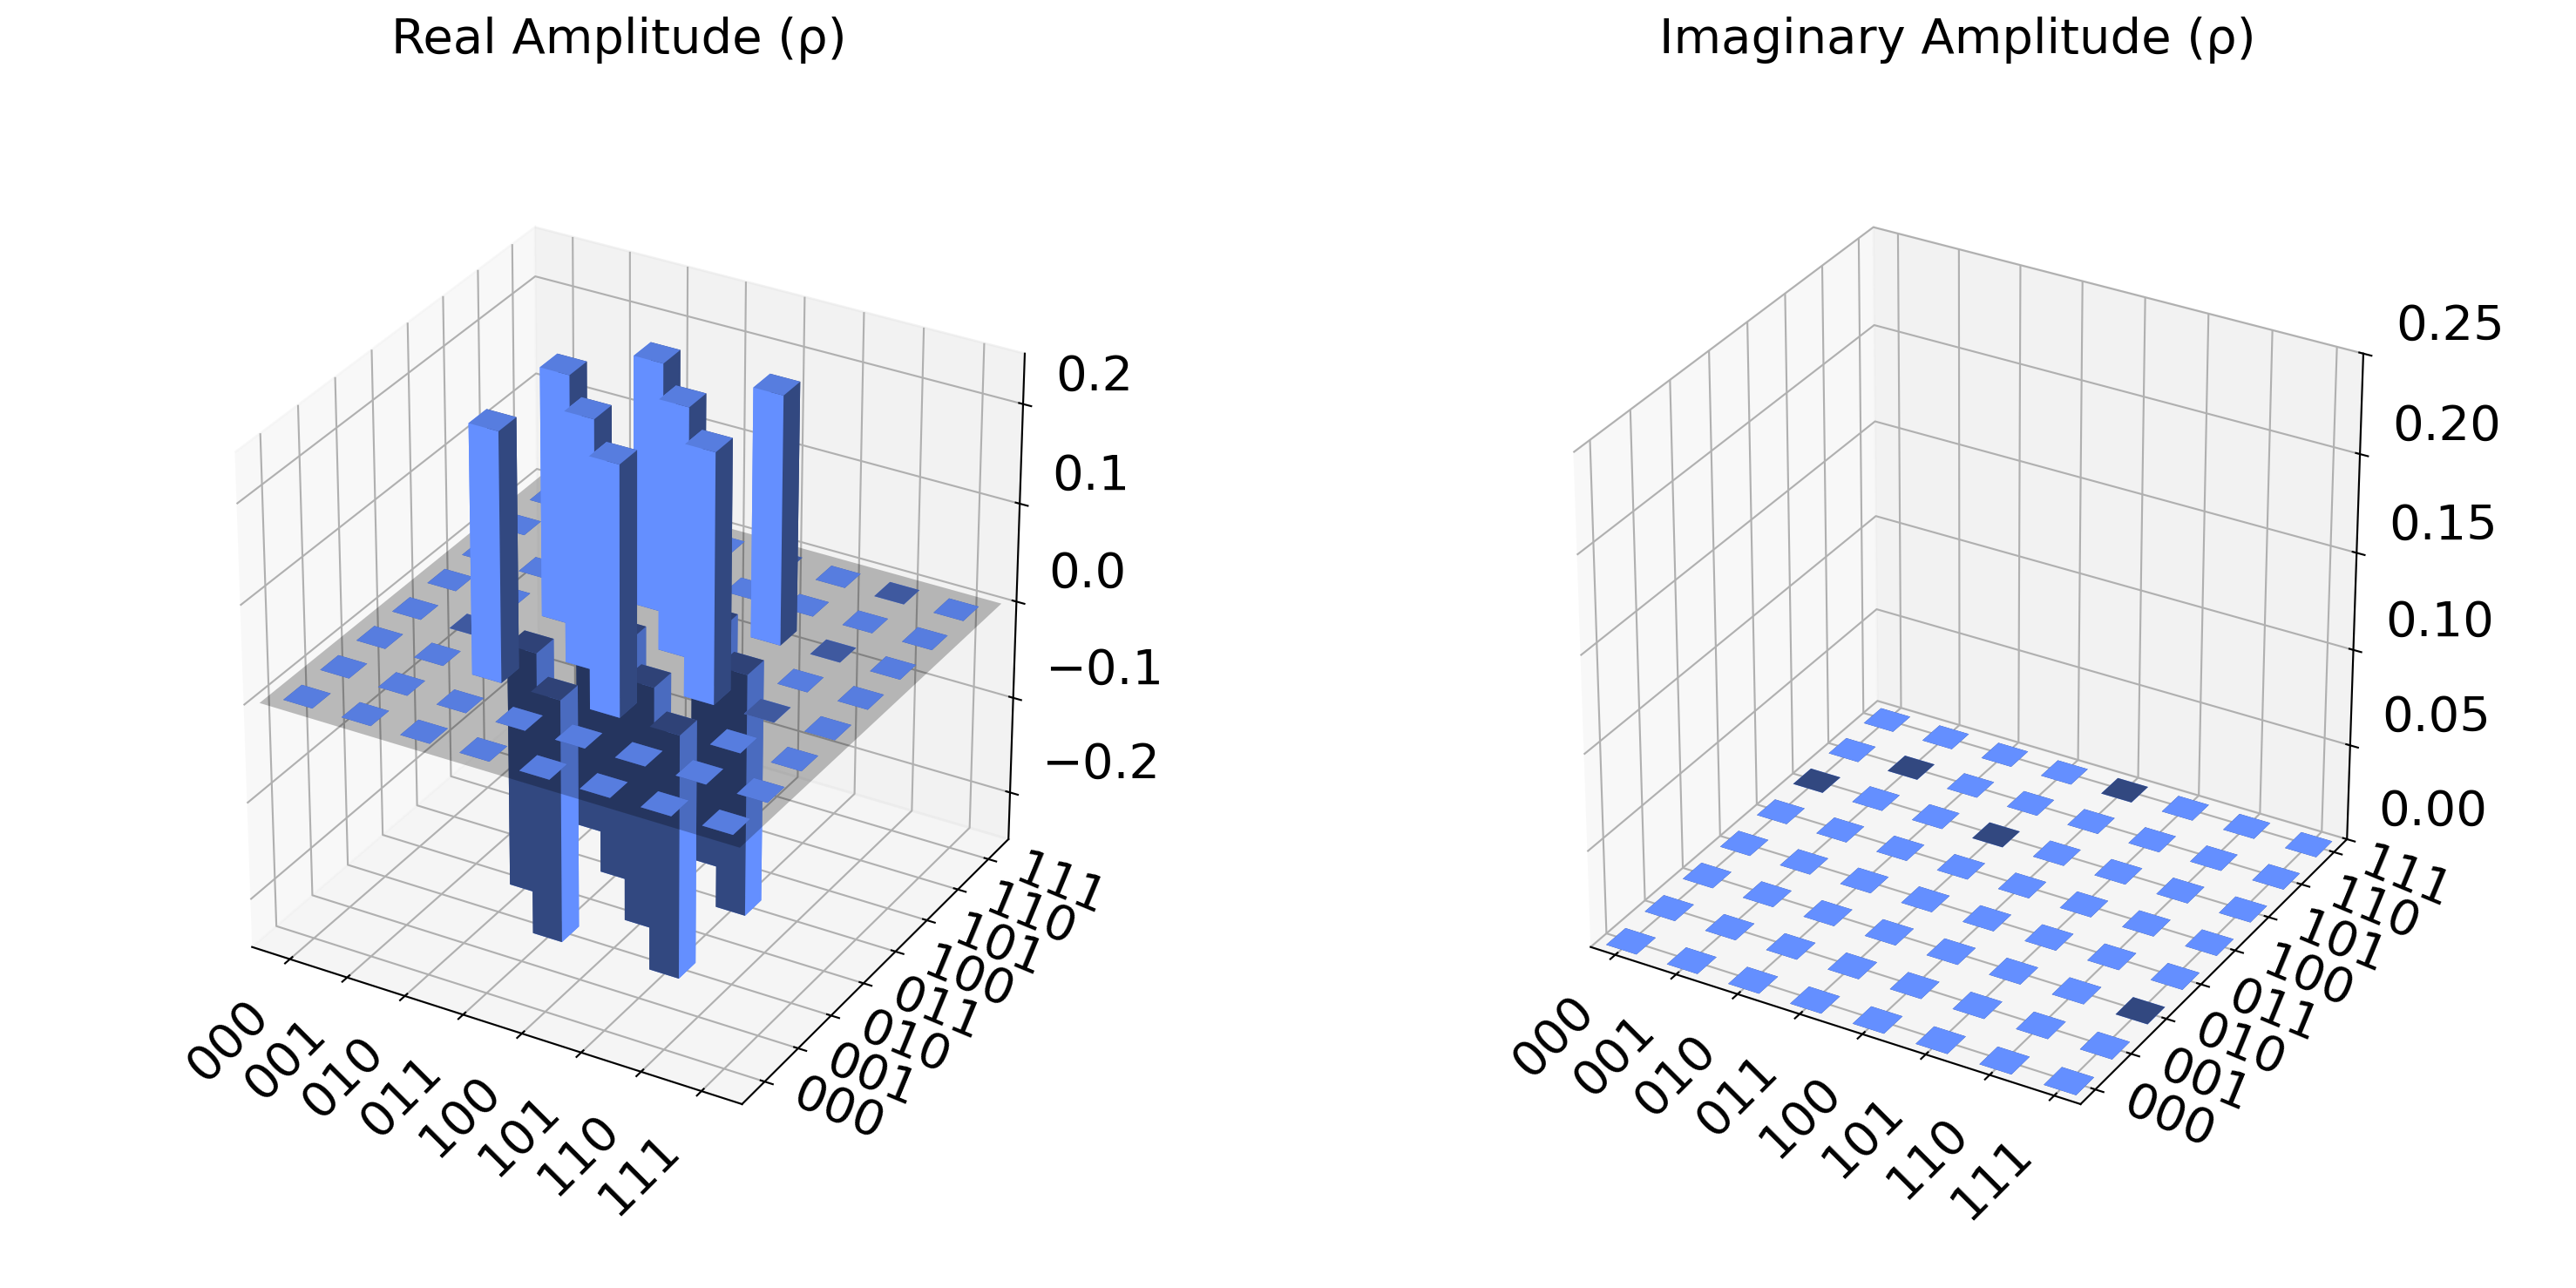

In [26]:
print("\n🏙️ State City - Estrutura completa do estado emaranhado:")
plot_state_city(state_final)


🌐 Q-Sphere - Todas as amplitudes:


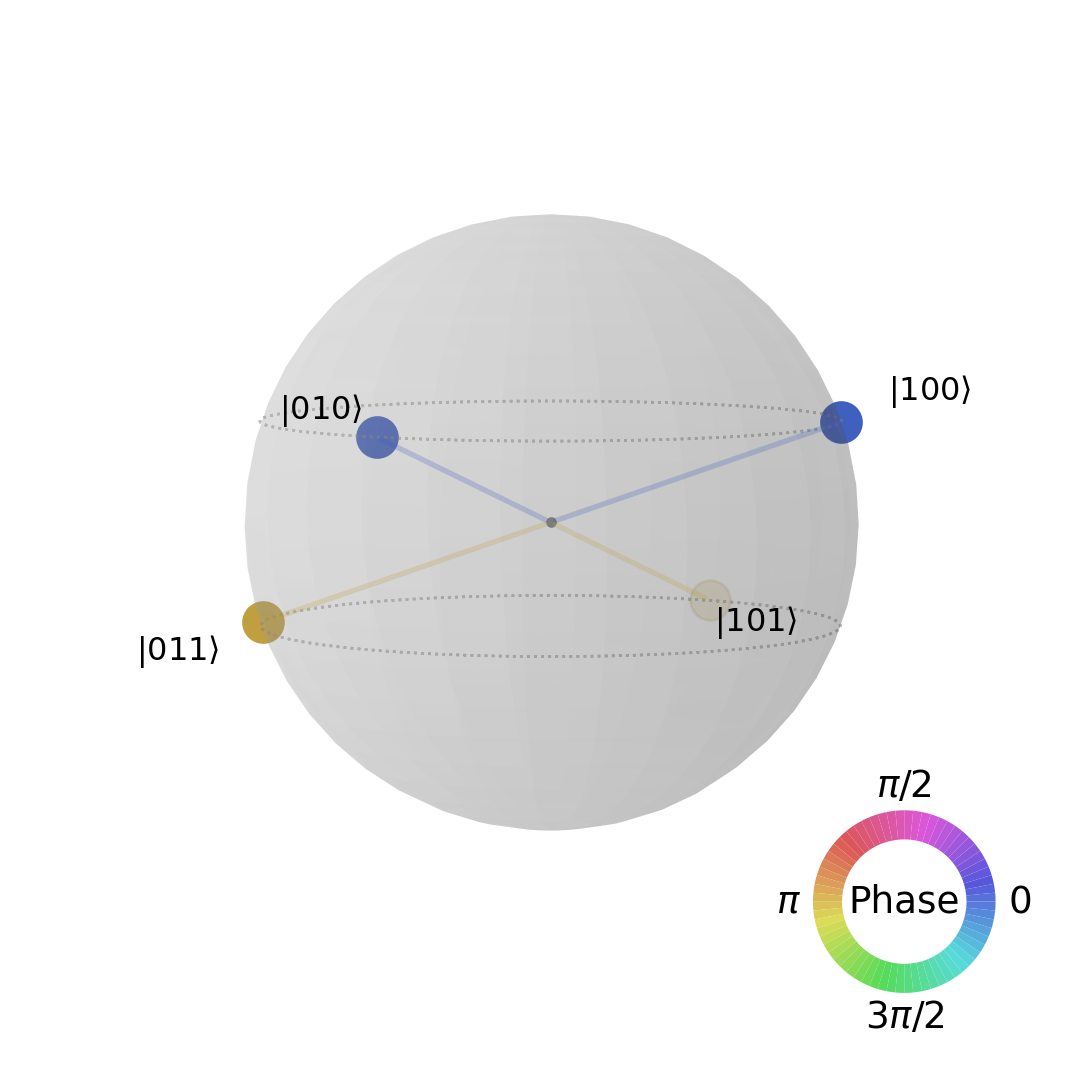

In [27]:
print("\n🌐 Q-Sphere - Todas as amplitudes:")
plot_state_qsphere(state_final)

In [28]:
# Executar o circuito completo e verificar os resultados
from qiskit_aer import AerSimulator

# Criar simulador
simulator = AerSimulator()

# Executar o circuito
job = simulator.run(circuit, shots=1000)
result = job.result()
counts = result.get_counts()

print("Resultados das medições (1000 execuções):")
print(counts)
print("\nO resultado esperado é '100' (qubit 2 = |1⟩, demonstrando o teletransporte)")

Resultados das medições (1000 execuções):
{'110': 277, '100': 252, '101': 246, '111': 225}

O resultado esperado é '100' (qubit 2 = |1⟩, demonstrando o teletransporte)
